# S6 - Explainable AI (XAI)

| Sekcija | Metoda | Scope |
|---------|--------|-------|
| 1 | **SHAP** | Globalna i lokalna analiza svih modela |
| 2 | **LIME** | Lokalna objašnjenja individualnih predikcija |
| 3 | **Permutation Feature Importance (PFI)** | Model-agnostična globalna metoda |
| 4 | **Stabilnost objašnjenja** | SHAP kroz 5 različitih seed-ova |
| 5 | **Cross-dataset usporedba** | SHAP ranking Dataset A vs Dataset B |

## Ulaz
- `data/processed/preprocessing_output.pkl`
- `models/baseline_models.pkl`
- `models/main_models.pkl`

In [ ]:
%pip install shap lime imblearn

In [ ]:
%pip install imblearn

In [1]:
import pickle, warnings, time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import shap
from lime import lime_tabular
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score, roc_auc_score

# Za stabilnost - isti modeli kao S5
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import os

warnings.filterwarnings('ignore')
shap.initjs()

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

CLR_POS = '#E8594C'
CLR_NEG = '#4C9BE8'
W = 66

os.makedirs('figures/xai', exist_ok=True)
print('Setup zavrsen.')

Setup zavrsen.


## 0. Učitavanje modela i podataka

In [2]:
# Podaci 
with open('data/processed/preprocessing_output.pkl', 'rb') as f:
    data = pickle.load(f)

X_a_train = data['X_a_train']; X_a_test = data['X_a_test']
y_a_train = data['y_a_train']; y_a_test = data['y_a_test']
feature_names_a = data['feature_names_a']

X_b_train = data['X_b_train']; X_b_test = data['X_b_test']
y_b_train = data['y_b_train']; y_b_test = data['y_b_test']
feature_names_b = data['feature_names_b']

# Baseline modeli (S4) 
with open('models/baseline_models.pkl', 'rb') as f:
    bl = pickle.load(f)
bl_models_a = bl['models_a'] # LR, RF
bl_models_b = bl['models_b']
baseline_df = bl['results_df']

# Main modeli (S5) 
with open('models/main_models.pkl', 'rb') as f:
    mn = pickle.load(f)
mn_models_a = mn['models_a'] # XGB, LGBM, CatBoost, TabNet, + tuned
mn_models_b = mn['models_b']
combined_df = mn['combined_df']

# Odabir modela za XAI 
# Svi trenirani modeli (bez tuned duplikata za cistoci)
all_models_a = {**bl_models_a, **{k: v for k, v in mn_models_a.items() if 'tuned' not in k.lower()}}
all_models_b = {**bl_models_b, **{k: v for k, v in mn_models_b.items() if 'tuned' not in k.lower()}}

# Dinamicki odaberi BEST model po ROC-AUC na Dataset A
best_row = (combined_df[(combined_df['Dataset'] == 'Dataset A') &
                         ~combined_df['Model'].str.contains('tuned', case=False)]
             .sort_values('ROC-AUC', ascending=False).iloc[0])
BEST_MODEL_NAME = best_row['Model']

TREE_MODELS = ['XGBoost', 'LightGBM', 'CatBoost', 'Random Forest']

# SHAP subsample (brze racunanje na velikom Dataset A)
SHAP_N_A = 3000
rng = np.random.default_rng(SEED)
idx_shap = rng.choice(len(X_a_test), min(SHAP_N_A, len(X_a_test)), replace=False)
X_shap_a = X_a_test[idx_shap]
y_shap_a = y_a_test[idx_shap]
X_shap_b = X_b_test  # Dataset B je mali, koristi sve
y_shap_b = y_b_test

print('Podaci i modeli ucitani.')
print(f'Dostupni modeli A: {list(all_models_a.keys())}')
print(f'Dostupni modeli B: {list(all_models_b.keys())}')
print()
print('=' * W)
print(f'BEST MODEL (po ROC-AUC, Dataset A): {BEST_MODEL_NAME}')
print(f'ROC-AUC: {best_row["ROC-AUC"]:.4f} F1(macro): {best_row["F1 (macro)"]:.4f}')
print('=' * W)
print(f'\nSHAP subsample: Dataset A = {len(X_shap_a)} | Dataset B = {len(X_shap_b)}')

Podaci i modeli ucitani.
Dostupni modeli A: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'TabNet']
Dostupni modeli B: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'TabNet']

BEST MODEL (po ROC-AUC, Dataset A): XGBoost
ROC-AUC: 0.8865 F1(macro): 0.6586

SHAP subsample: Dataset A = 3000 | Dataset B = 184


## 1. SHAP - Globalna analiza

SHAP (SHapley Additive exPlanations) dodjeljuje svakom featuru doprinos predikciji na osnovu Shapleyevih vrijednosti iz teorije igara. Zadovoljava tri ključna aksioma: efikasnost, simetriju i null-igrača. Koristimo:
- `TreeExplainer` za sve tree-based modele (tačne Shapley vrijednosti u polinomnom vremenu)
- `LinearExplainer` za Logistic Regression

In [3]:
def compute_shap(model, X_sample, model_name, bg_data=None):
    """
    Racuna SHAP vrijednosti za binarnu klasifikaciju.
    - LR -> LinearExplainer
    - Random Forest -> TreeExplainer + approximate=True (duboka stabla)
    - XGB/LGBM/Cat -> TreeExplainer (exact)
    - TabNet -> preskocen (koristi attention-based FI iz S5)
    """
    if model_name == "Logistic Regression":
        explainer = shap.LinearExplainer(model, bg_data if bg_data is not None else X_sample)
        sv = explainer.shap_values(X_sample)
    elif model_name == "Random Forest":
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_sample, check_additivity=False, approximate=True)
    elif model_name == "TabNet":
        # TabNet nema TreeExplainer podrsku; koristi vlastiti attention mehanizam
        # Feature importance je vec izracunat u S5 (tab_a.feature_importances_)
        return None, None
    else:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_sample, check_additivity=False)

    if isinstance(sv, list):
        sv = sv[1] if len(sv) == 2 else sv[0]
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    return explainer, sv


# Izracun SHAP za sve modele na oba dataseta
shap_values_a = {}
shap_values_b = {}

bg_a = X_a_train[np.random.choice(len(X_a_train), 500, replace=False)]
bg_b = X_b_train

print("Racunanje SHAP vrijednosti...")
print()

for mname, model in all_models_a.items():
    print(f"SHAP -> {mname} | Dataset A ({len(X_shap_a)} uzoraka)...", end=" ", flush=True)
    t0 = time.time()
    _, sv_a = compute_shap(model, X_shap_a, mname, bg_a)
    if sv_a is None:
        print("preskocan (TabNet koristi attention FI)")
        continue
    shap_values_a[mname] = sv_a
    print(f"{time.time()-t0:.1f}s")

for mname, model in all_models_b.items():
    print(f"SHAP -> {mname} | Dataset B ({len(X_shap_b)} uzoraka)...", end=" ", flush=True)
    t0 = time.time()
    _, sv_b = compute_shap(model, X_shap_b, mname, bg_b)
    if sv_b is None:
        print("preskocan (TabNet koristi attention FI)")
        continue
    shap_values_b[mname] = sv_b
    print(f"{time.time()-t0:.1f}s")

print(f"SHAP izracun zavrsen za {len(shap_values_a)} modela.")

Racunanje SHAP vrijednosti...

SHAP -> Logistic Regression | Dataset A (3000 uzoraka)... 0.0s
SHAP -> Random Forest | Dataset A (3000 uzoraka)... 0.6s
SHAP -> XGBoost | Dataset A (3000 uzoraka)... 1.7s
SHAP -> LightGBM | Dataset A (3000 uzoraka)... 3.1s
SHAP -> CatBoost | Dataset A (3000 uzoraka)... 0.8s
SHAP -> TabNet | Dataset A (3000 uzoraka)... preskocan (TabNet koristi attention FI)
SHAP -> Logistic Regression | Dataset B (184 uzoraka)... 0.0s
SHAP -> Random Forest | Dataset B (184 uzoraka)... 0.0s
SHAP -> XGBoost | Dataset B (184 uzoraka)... 0.3s
SHAP -> LightGBM | Dataset B (184 uzoraka)... 0.3s
SHAP -> CatBoost | Dataset B (184 uzoraka)... 0.3s
SHAP -> TabNet | Dataset B (184 uzoraka)... preskocan (TabNet koristi attention FI)
SHAP izracun zavrsen za 5 modela.


In [4]:
# SHAP top-N ranking tabela (za svaki model) 

TOP_K = 10

def shap_ranking(sv, feature_names, top_k=10):
    """Vraca sorted DataFrame s mean |SHAP| po featuru."""
    mean_abs = np.abs(sv).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:top_k]
    return pd.DataFrame({
        'Rank': range(1, top_k + 1),
        'Feature': [feature_names[i] for i in idx],
        'Mean |SHAP|': mean_abs[idx].round(5),
        'feature_idx': idx,
    })


all_rankings_a = {m: shap_ranking(sv, feature_names_a, TOP_K)
                  for m, sv in shap_values_a.items()}
all_rankings_b = {m: shap_ranking(sv, feature_names_b, TOP_K)
                  for m, sv in shap_values_b.items()}

W2 = 56

for ds_label, rankings in [
    ('Dataset A - CDC 2022', all_rankings_a),
    ('Dataset B - Heart Failure', all_rankings_b),
]:
    print()
    print('=' * (W2 * len(rankings) + 4))
    print(f'SHAP Top-{TOP_K} Feature Importance | {ds_label}')
    print('=' * (W2 * len(rankings) + 4))

    # Header
    header = ''.join(f'{mname:<52}' for mname in rankings.keys())
    print(header)
    print('-' * (W2 * len(rankings) + 4))

    for rank in range(1, TOP_K + 1):
        row = ''
        for mname, df_rank in rankings.items():
            feat = df_rank.loc[df_rank['Rank'] == rank, 'Feature'].values[0]
            val = df_rank.loc[df_rank['Rank'] == rank, 'Mean |SHAP|'].values[0]
            row += f'  {rank:2d}. {feat:<38} {val:.5f}  '
        print(row)

    print('=' * (W2 * len(rankings) + 4))


SHAP Top-10 Feature Importance | Dataset A - CDC 2022
Logistic Regression                                 Random Forest                                       XGBoost                                             LightGBM                                            CatBoost                                            
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   1. HadAngina                              0.80888     1. HadAngina                              0.09917     1. HadAngina                              0.74290     1. HadAngina                              0.79903     1. AgeCategory                            1.00806  
   2. AgeCategory                            0.70399     2. AgeCategory                            0.09029     2. AgeCategory   

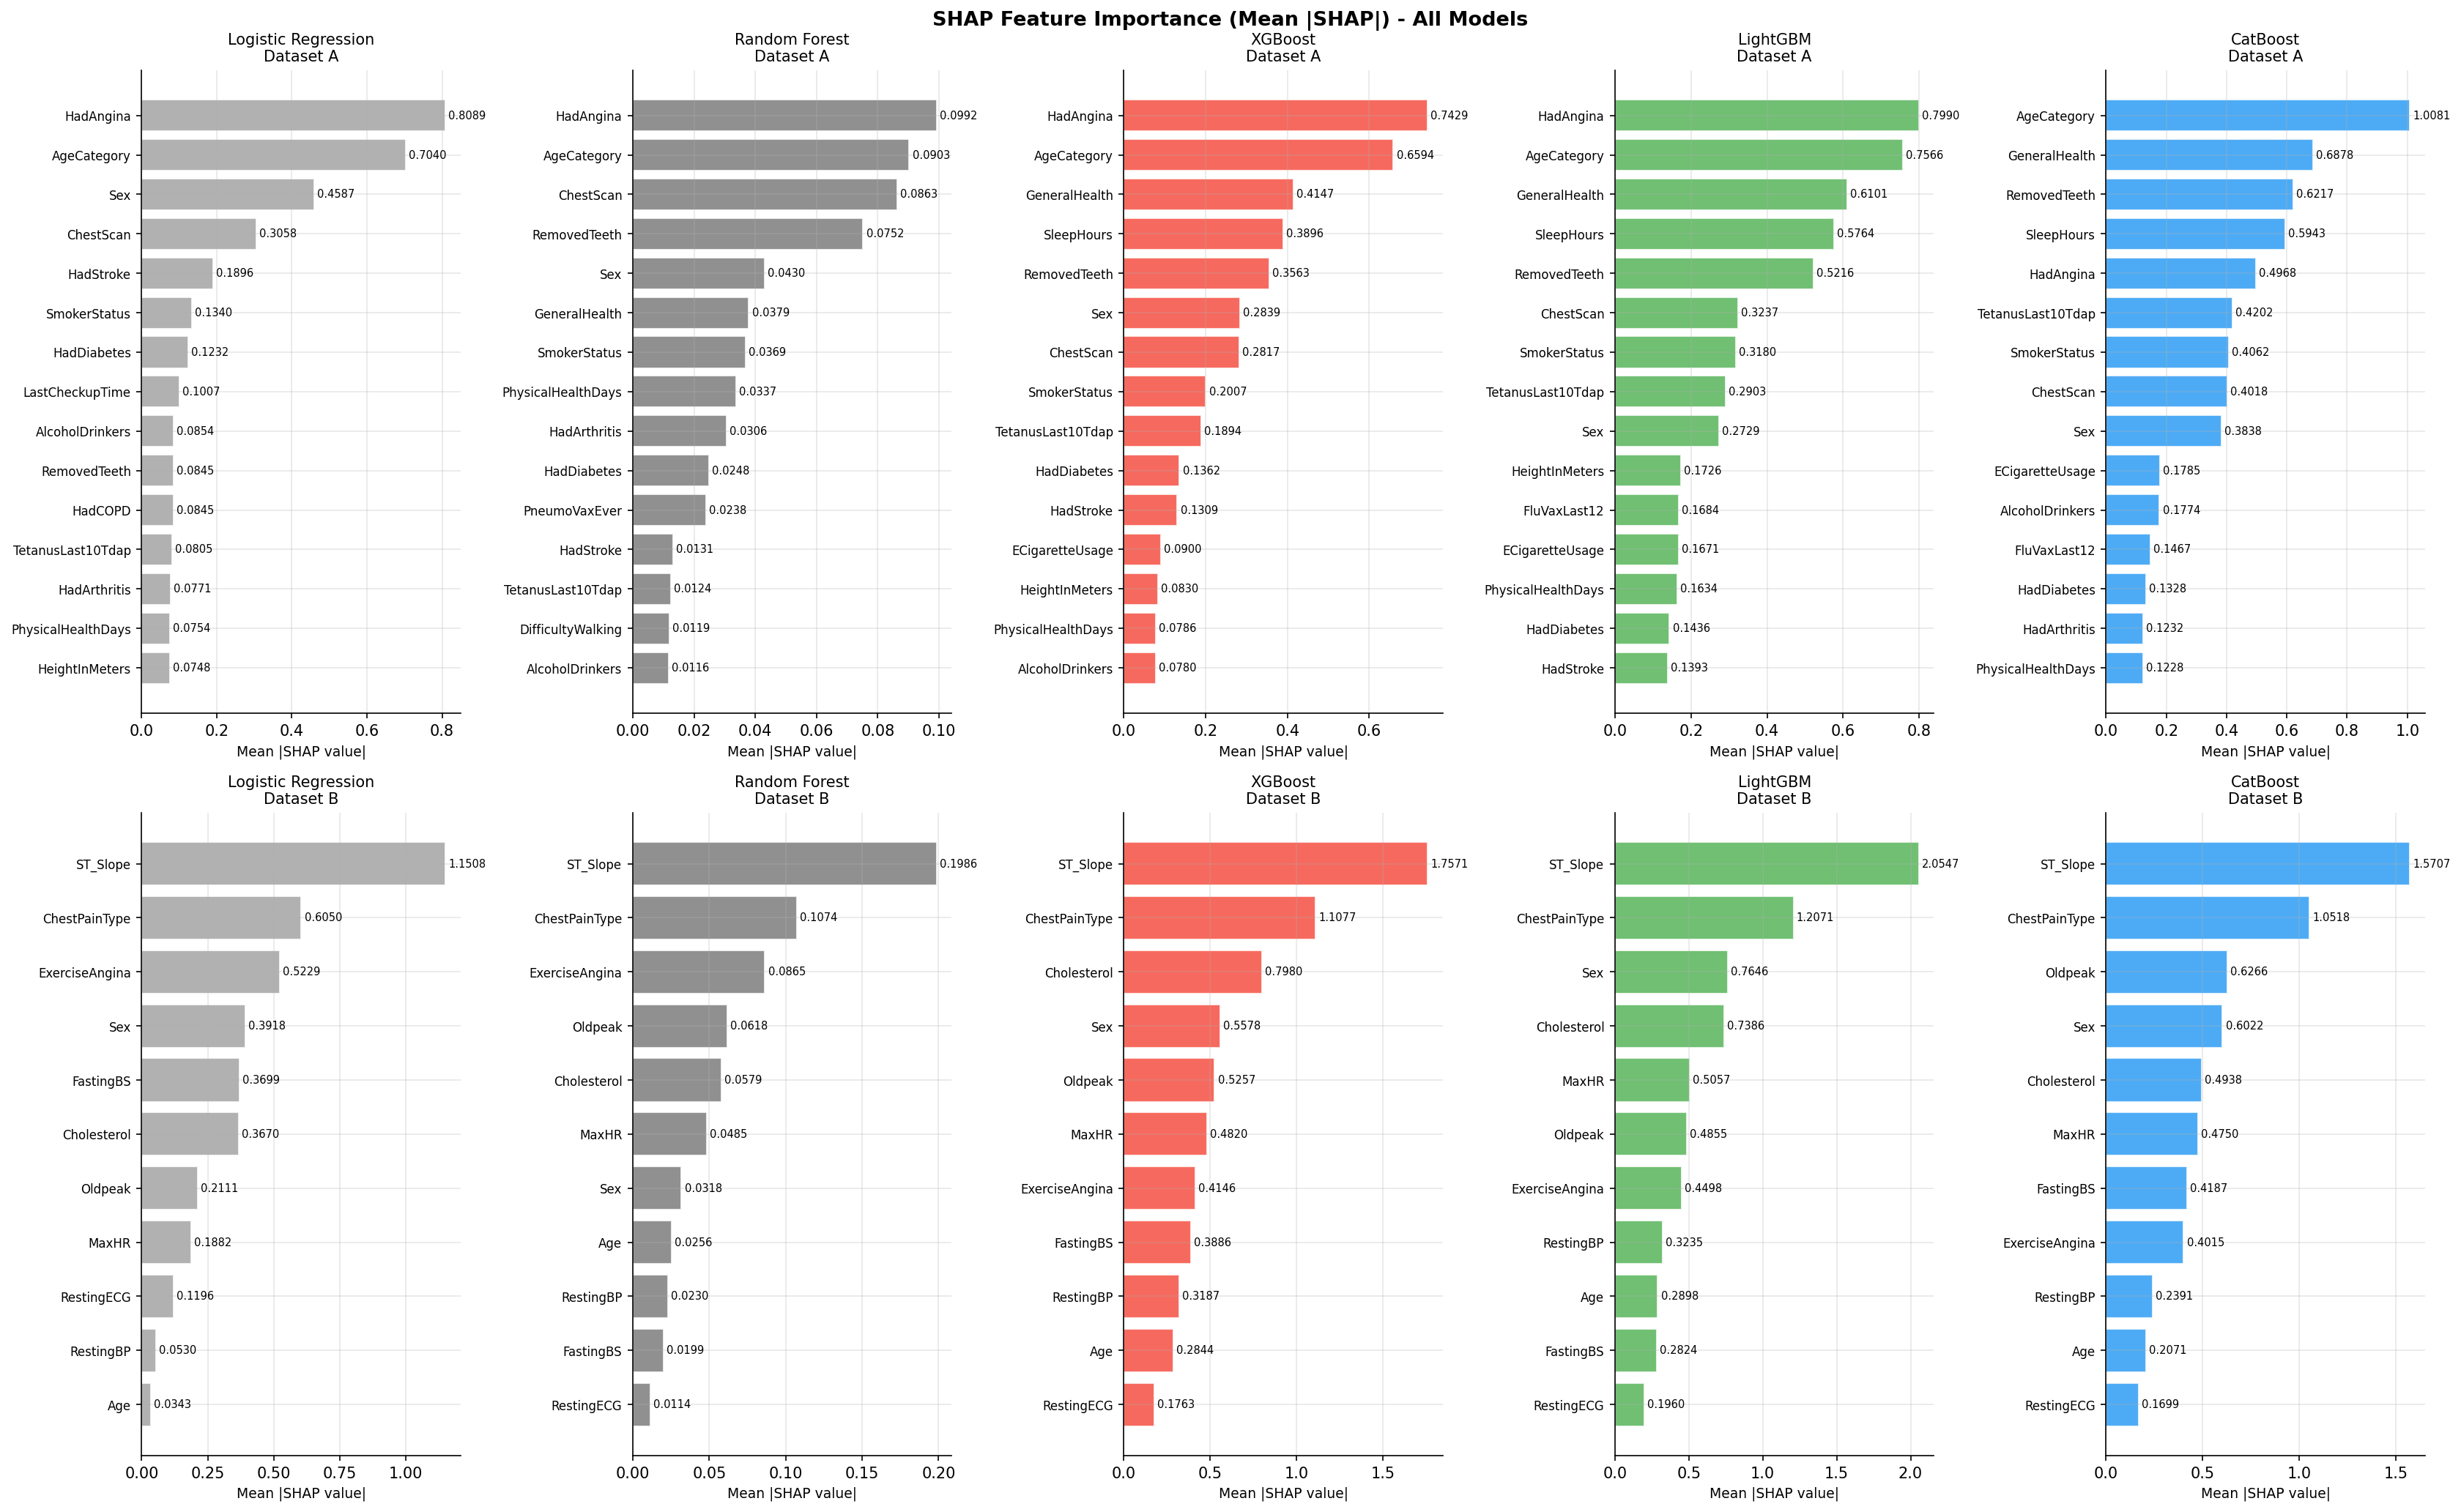

Sacuvano: figures/xai/S6_shap_bar.png


In [5]:
# SHAP Bar Plots - globalna vaznost (mean |SHAP|) 

n_models = len(shap_values_a)
fig, axes = plt.subplots(2, n_models, figsize=(4.5 * n_models, 14))
if n_models == 1:
    axes = axes.reshape(2, 1)

MODEL_COLORS_XAI = {
    'Logistic Regression': '#9E9E9E', 'Random Forest': '#757575',
    'XGBoost': '#F44336', 'LightGBM': '#4CAF50', 'CatBoost': '#2196F3', 'TabNet': '#9C27B0',
}

for col, mname in enumerate(shap_values_a.keys()):
    color = MODEL_COLORS_XAI.get(mname, '#607D8B')

    for row, (sv, feat_names, ds_lbl) in enumerate([
        (shap_values_a[mname], feature_names_a, 'Dataset A'),
        (shap_values_b.get(mname, None), feature_names_b, 'Dataset B'),
    ]):
        ax = axes[row, col]
        if sv is None:
            ax.axis('off'); continue

        mean_abs = np.abs(sv).mean(axis=0)
        top_idx = np.argsort(mean_abs)[::-1][:15]
        top_f = [feat_names[i] for i in top_idx]
        top_v = mean_abs[top_idx]
        top_n = len(top_idx)  

        ax.barh(range(top_n), top_v[::-1], color=color, alpha=0.80, edgecolor='white')
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(top_f[::-1], fontsize=8)
        ax.set_xlabel('Mean |SHAP value|', fontsize=9)
        ax.set_title(f'{mname}\n{ds_lbl}', fontsize=10)
        for i, v in enumerate(top_v[::-1]):
            ax.text(v + top_v.max() * 0.01, i, f'{v:.4f}', va='center', fontsize=7)

plt.suptitle('SHAP Feature Importance (Mean |SHAP|) - All Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/xai/S6_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/xai/S6_shap_bar.png')

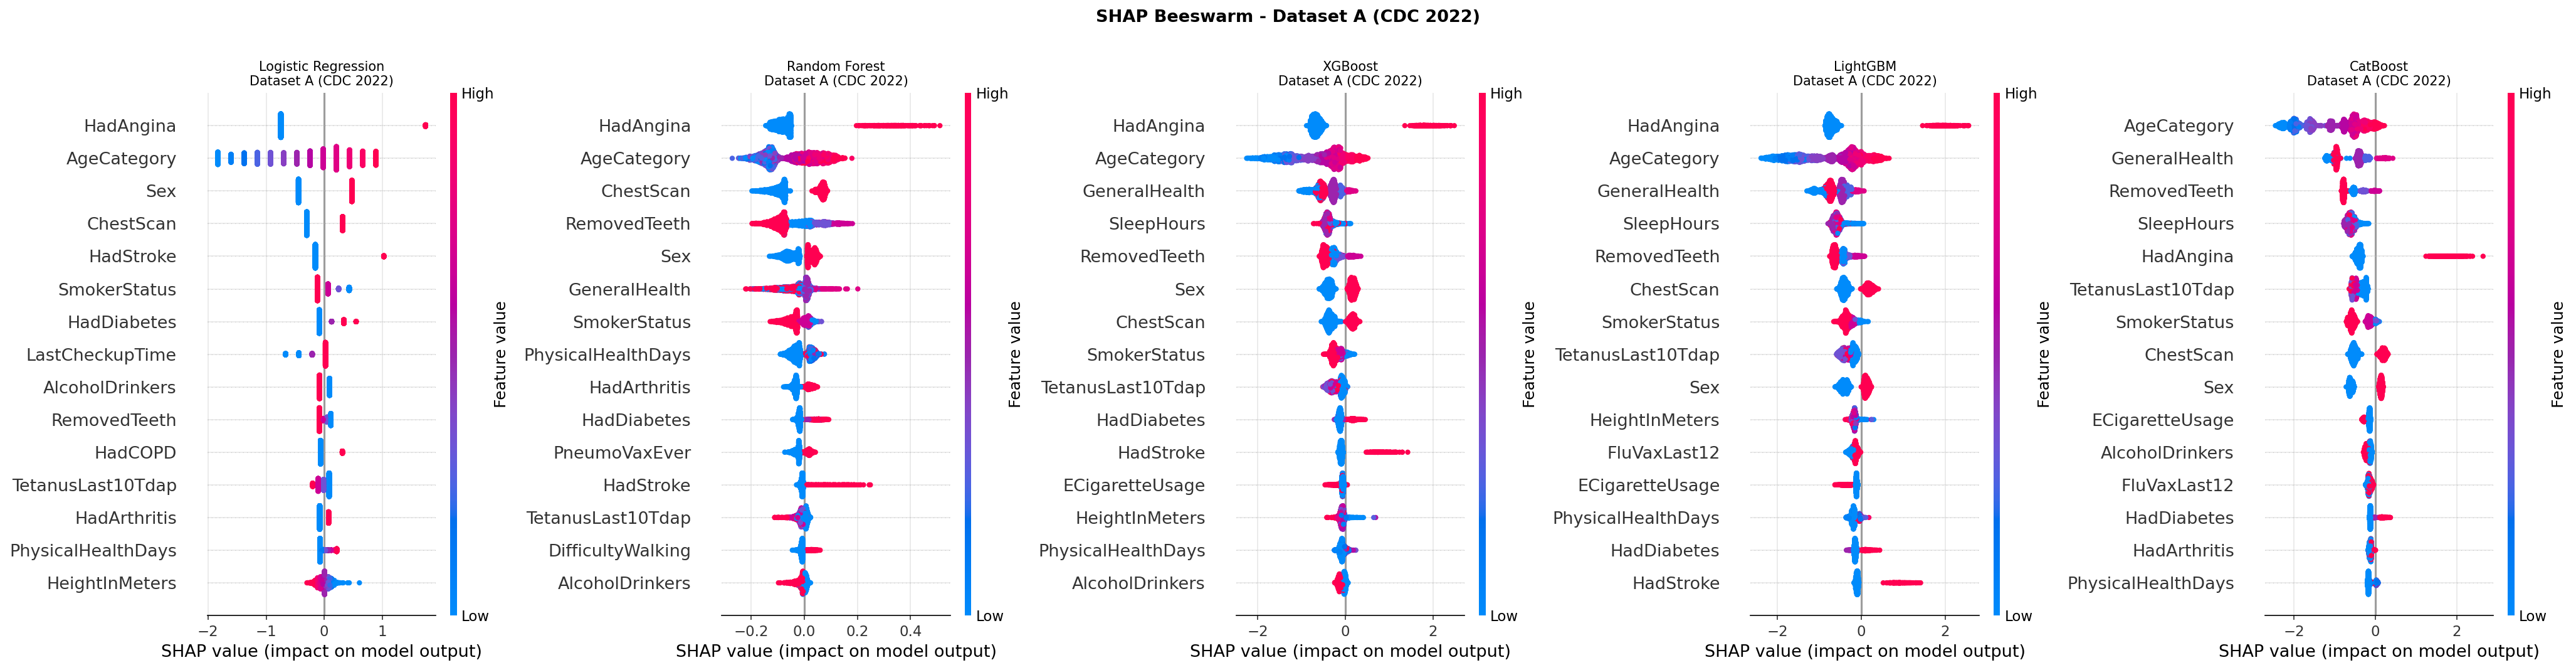

Sacuvano: figures/xai/S6_shap_beeswarm_A.png


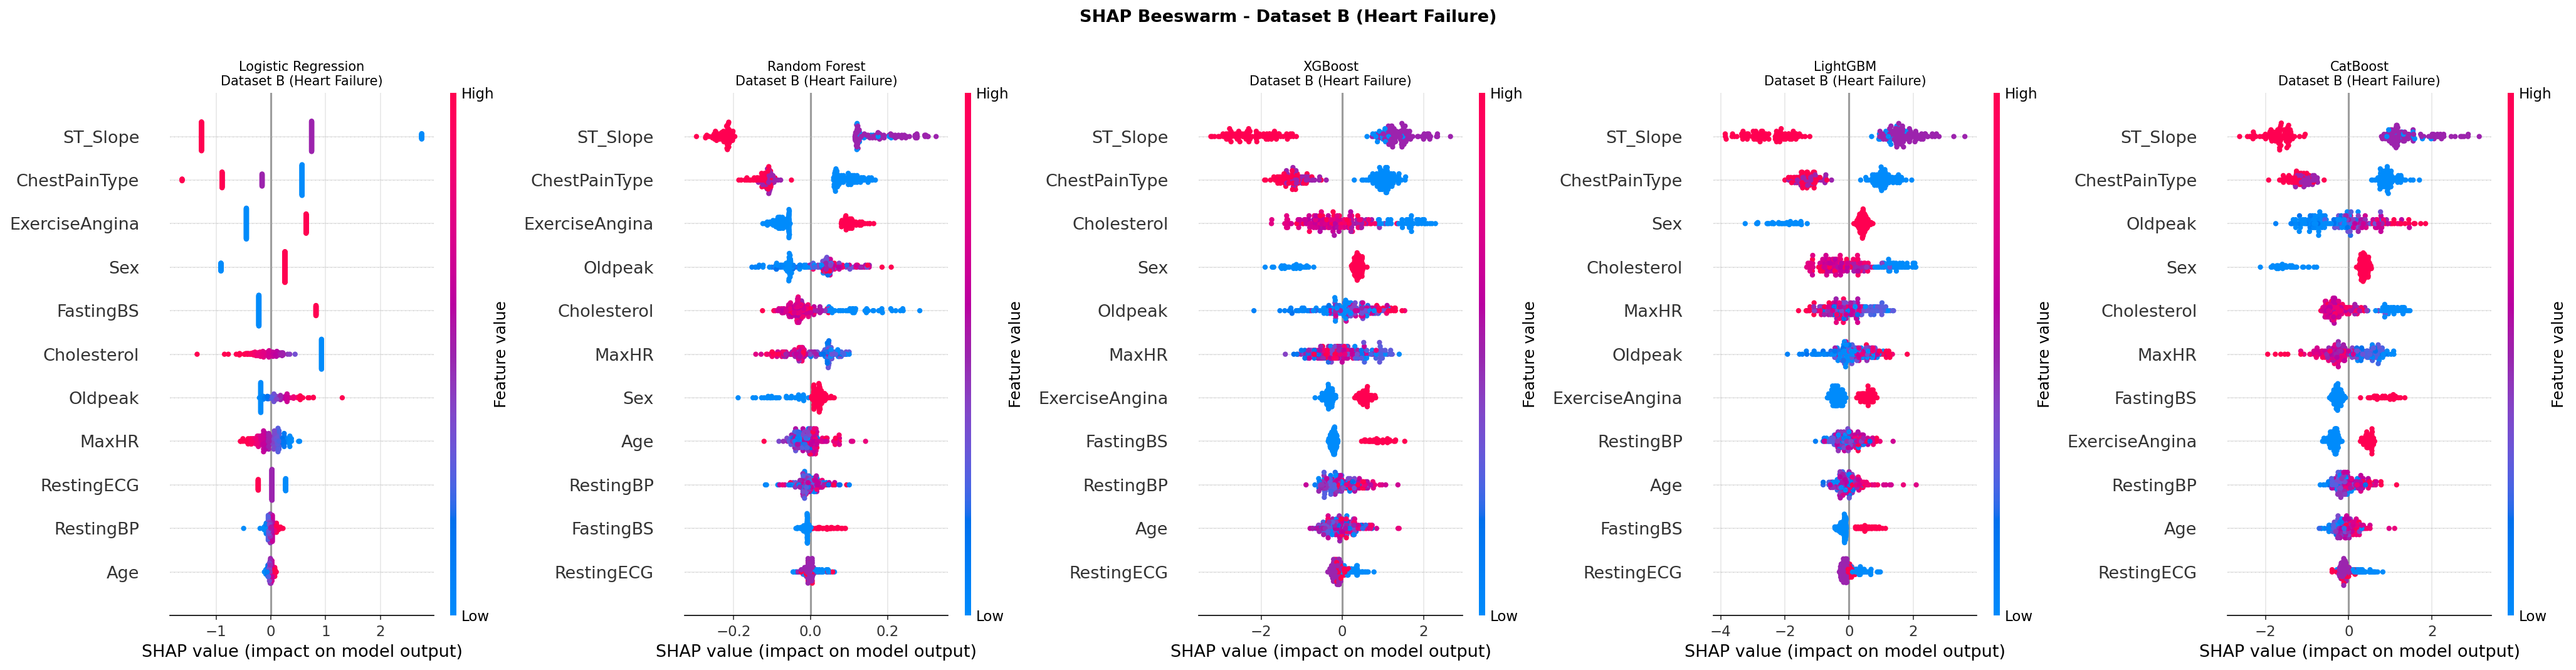

Sacuvano: figures/xai/S6_shap_beeswarm_B.png


In [6]:
# SHAP Beeswarm (Summary) Plots 

for ds_key, shap_dict, X_sample, feat_names, ds_lbl in [
    ('A', shap_values_a, X_shap_a, feature_names_a, 'Dataset A (CDC 2022)'),
    ('B', shap_values_b, X_shap_b, feature_names_b, 'Dataset B (Heart Failure)'),
]:
    n = len(shap_dict)
    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 7))
    if n == 1:
        axes = [axes]

    for ax, (mname, sv) in zip(axes, shap_dict.items()):
        plt.sca(ax)
        shap.summary_plot(
            sv, X_sample,
            feature_names=feat_names,
            max_display=15,
            show=False,
            plot_size=None
        )
        ax.set_title(f'{mname}\n{ds_lbl}', fontsize=10)

    plt.suptitle(f'SHAP Beeswarm - {ds_lbl}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    fname = f'figures/xai/S6_shap_beeswarm_{ds_key}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Sacuvano: {fname}')

SHAP Waterfall — XGBoost | Dataset A
True Positive (TP)         idx= 24255  P(HD)=0.9551  Pred=1  True=1
False Negative (FN)        idx= 15605  P(HD)=0.0008  Pred=0  True=1
True Negative (TN)         idx= 20268  P(HD)=0.0002  Pred=0  True=0
False Positive (FP)        idx= 83057  P(HD)=0.8897  Pred=1  True=0


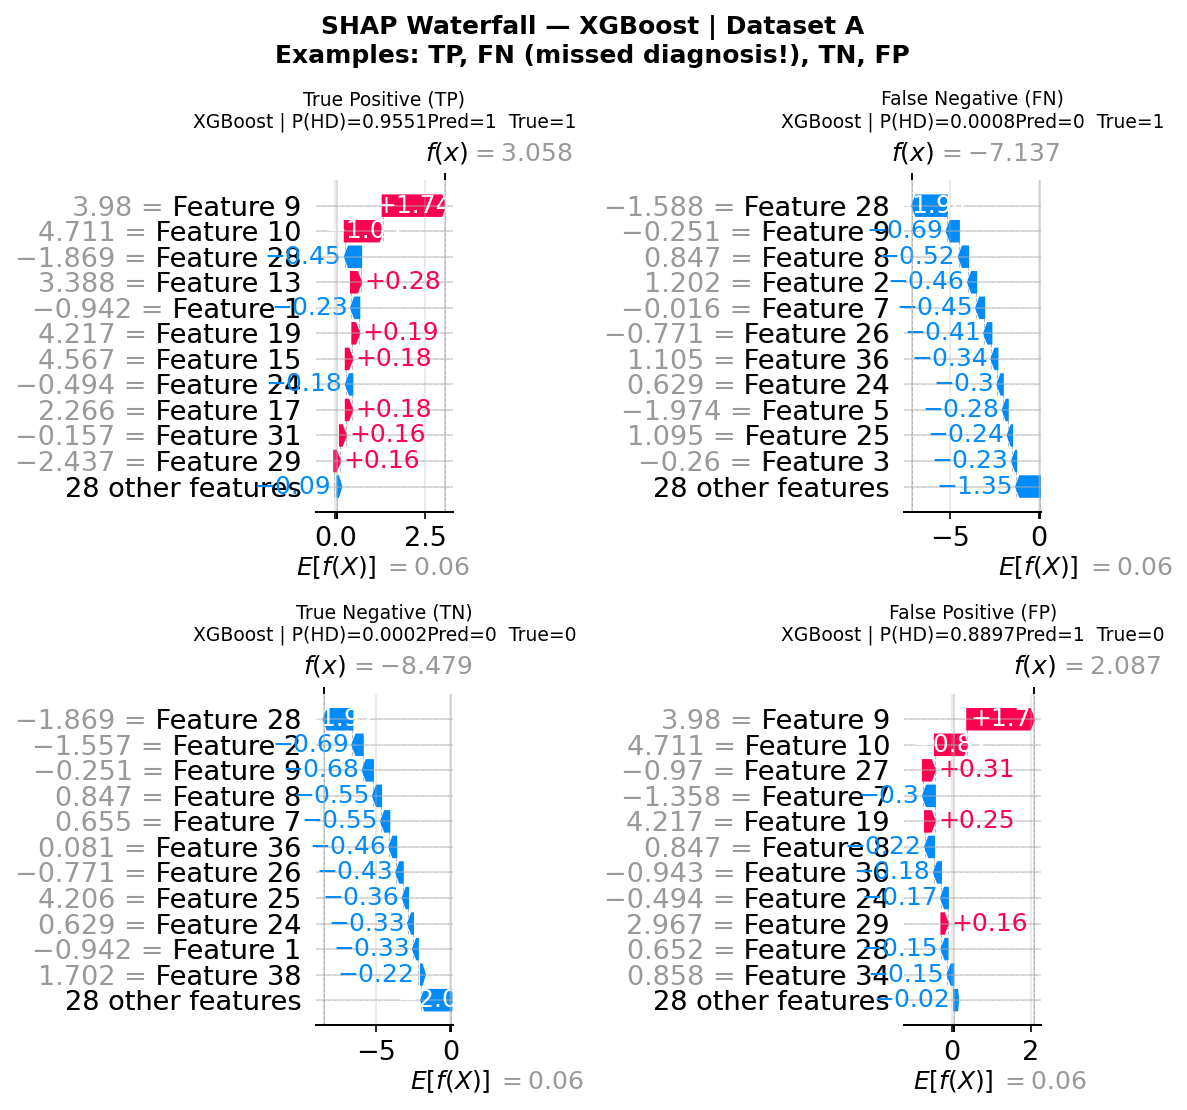

Sacuvano: figures/xai/S6_shap_waterfall.png


In [7]:
# SHAP Waterfall - individualne predikcije (TP, FN, TN, FP) 

best_model_a = all_models_a[BEST_MODEL_NAME]
y_pred_a = best_model_a.predict(X_a_test)
y_prob_a = best_model_a.predict_proba(X_a_test)[:, 1]

tp_idx = np.where((y_pred_a == 1) & (y_a_test == 1))[0]
fn_idx = np.where((y_pred_a == 0) & (y_a_test == 1))[0]
tn_idx = np.where((y_pred_a == 0) & (y_a_test == 0))[0]
fp_idx = np.where((y_pred_a == 1) & (y_a_test == 0))[0]

# Odabir po confidence (najsigurniji primjer iz svake kategorije)
examples = {
    'True Positive (TP)': tp_idx[np.argmax(y_prob_a[tp_idx])],
    'False Negative (FN)': fn_idx[np.argmin(y_prob_a[fn_idx])],
    'True Negative (TN)': tn_idx[np.argmin(y_prob_a[tn_idx])],
    'False Positive (FP)': fp_idx[np.argmax(y_prob_a[fp_idx])],
}

print('=' * W)
print(f'SHAP Waterfall — {BEST_MODEL_NAME} | Dataset A')
print('=' * W)
for lbl, i in examples.items():
    print(f'{lbl:<26} idx={i:>6}  '
          f'P(HD)={y_prob_a[i]:.4f}  '
          f'Pred={y_pred_a[i]}  True={y_a_test[i]}')
print('=' * W)

explainer_best_a = shap.TreeExplainer(best_model_a)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (lbl, i) in zip(axes, examples.items()):
    plt.sca(ax)
    sv_single = explainer_best_a(X_a_test[i:i+1], check_additivity=False)
    # Normalizacija za waterfall
    if hasattr(sv_single, 'values'):
        sv_plot = sv_single
        if sv_plot.values.ndim == 3:
            sv_plot.values = sv_plot.values[:, :, 1]
            sv_plot.base_values = sv_plot.base_values[:, 1]
    shap.plots.waterfall(sv_plot[0], max_display=12, show=False)
    ax.set_title(
        f'{lbl}\n{BEST_MODEL_NAME} | P(HD)={y_prob_a[i]:.4f}'
        f'Pred={y_pred_a[i]}  True={y_a_test[i]}',
        fontsize=9
    )

plt.suptitle(f'SHAP Waterfall — {BEST_MODEL_NAME} | Dataset A\n'
             f'Examples: TP, FN (missed diagnosis!), TN, FP',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/xai/S6_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/xai/S6_shap_waterfall.png')

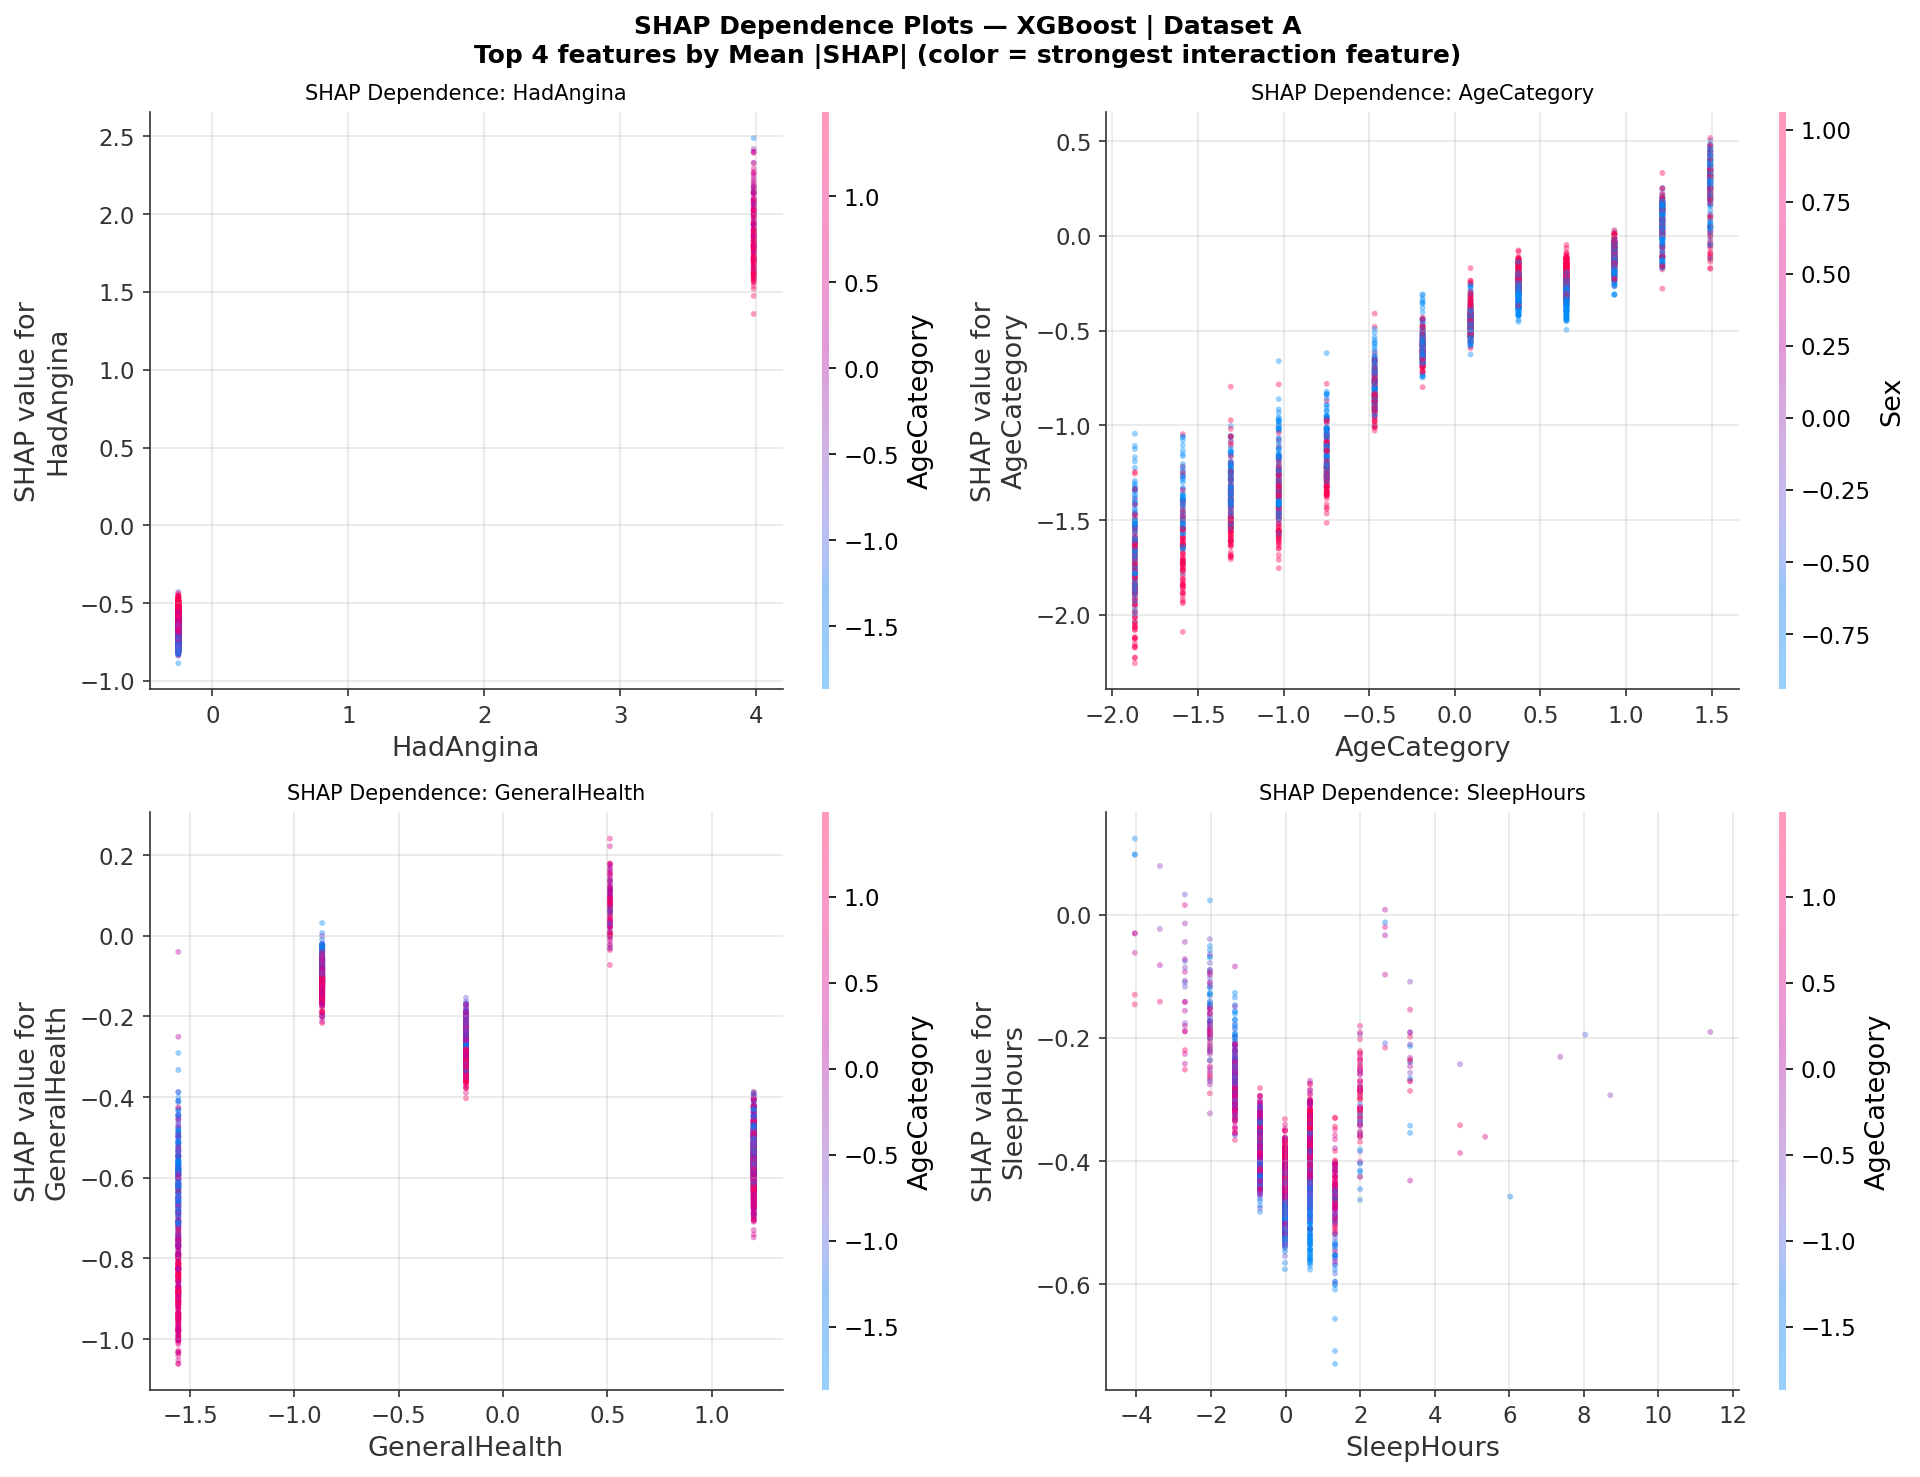

Sacuvano: figures/xai/S6_shap_dependence.png


In [8]:
# SHAP Dependence Plots - top 4 featura (best model, Dataset A)

sv_best_a = shap_values_a[BEST_MODEL_NAME]
mean_abs_best = np.abs(sv_best_a).mean(axis=0)
top4_idx = np.argsort(mean_abs_best)[::-1][:4]
top4_names = [feature_names_a[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, feat_idx in zip(axes, top4_idx):
    plt.sca(ax)
    shap.dependence_plot(
        feat_idx,
        sv_best_a,
        X_shap_a,
        feature_names=feature_names_a,
        interaction_index='auto',
        ax=ax,
        show=False,
        alpha=0.4,
        dot_size=8
    )
    ax.set_title(f'SHAP Dependence: {feature_names_a[feat_idx]}', fontsize=10)

plt.suptitle(
    f'SHAP Dependence Plots — {BEST_MODEL_NAME} | Dataset A\n'
    'Top 4 features by Mean |SHAP| (color = strongest interaction feature)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figures/xai/S6_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/xai/S6_shap_dependence.png')


Spearman rang-korelacija SHAP rankinga  |  Dataset A
                          Logistic Regre   Random Forest         XGBoost        LightGBM        CatBoost
--------------------------------------------------------------------------------------------------------------
  Logistic Regression               1.0000          0.7324          0.7091          0.6757          0.6528
  Random Forest                     0.7324          1.0000          0.8822          0.8791          0.8943
  XGBoost                           0.7091          0.8822          1.0000          0.9690          0.9470
  LightGBM                          0.6757          0.8791          0.9690          1.0000          0.9709
  CatBoost                          0.6528          0.8943          0.9470          0.9709          1.0000


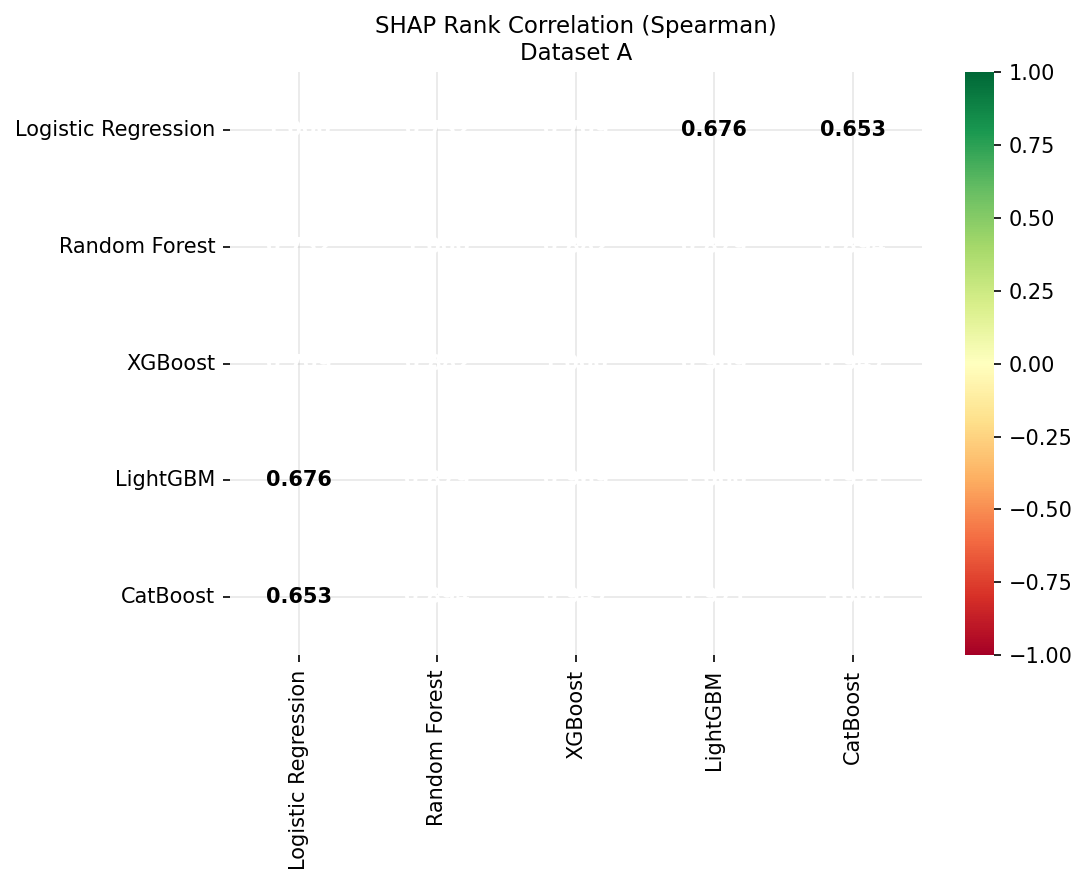

Sacuvano: figures/xai/S6_shap_agreement_A.png

Spearman rang-korelacija SHAP rankinga  |  Dataset B
                          Logistic Regre   Random Forest         XGBoost        LightGBM        CatBoost
--------------------------------------------------------------------------------------------------------------
  Logistic Regression               1.0000          0.7182          0.7818          0.6909          0.7455
  Random Forest                     0.7182          1.0000          0.8273          0.8182          0.7818
  XGBoost                           0.7818          0.8273          1.0000          0.9545          0.9545
  LightGBM                          0.6909          0.8182          0.9545          1.0000          0.8909
  CatBoost                          0.7455          0.7818          0.9545          0.8909          1.0000


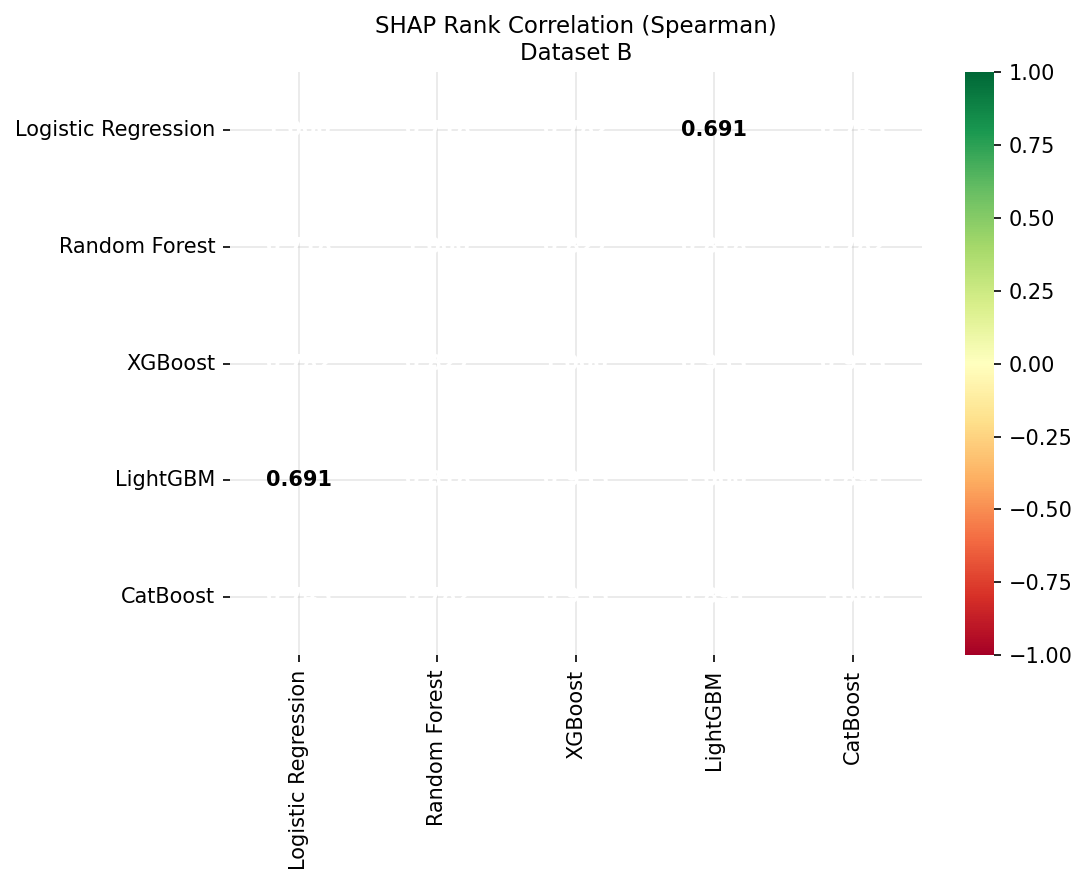

Sacuvano: figures/xai/S6_shap_agreement_B.png


In [9]:
# Medu-modelska konzistentnost SHAP rankinga 

def get_rank_vector(sv, n_features):
    mean_abs = np.abs(sv).mean(axis=0)
    ranks = np.argsort(np.argsort(-mean_abs))  # rank (0 = najvaznije)
    return ranks


for ds_label, shap_dict, feat_names in [
    ('Dataset A', shap_values_a, feature_names_a),
    ('Dataset B', shap_values_b, feature_names_b),
]:
    model_list = list(shap_dict.keys())
    n = len(model_list)
    if n < 2:
        continue

    rank_vecs = {m: get_rank_vector(shap_dict[m], len(feat_names)) for m in model_list}

    corr_matrix = np.zeros((n, n))
    for i, m1 in enumerate(model_list):
        for j, m2 in enumerate(model_list):
            corr, _ = spearmanr(rank_vecs[m1], rank_vecs[m2])
            corr_matrix[i, j] = corr

    # Print
    W3 = 16 * n + 30
    print()
    print('=' * W3)
    print(f'Spearman rang-korelacija SHAP rankinga  |  {ds_label}')
    print('=' * W3)
    hdr = f'{"":24}' + ''.join(f'{m[:14]:>16}' for m in model_list)
    print(hdr)
    print('-' * W3)
    for i, m1 in enumerate(model_list):
        row = f'  {m1:<24}'
        for j in range(n):
            row += f'{corr_matrix[i,j]:>16.4f}'
        print(row)
    print('=' * W3)

    # Heatmap
    fig, ax = plt.subplots(figsize=(max(5, n * 1.5), max(4, n * 1.2)))
    mask = np.eye(n, dtype=bool)
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=model_list, yticklabels=model_list,
                vmin=-1, vmax=1, ax=ax, mask=~mask | mask,
                linewidths=0.5, annot_kws={'size': 10, 'weight': 'bold'})
    # Overlay sa svim vrijednostima
    for i in range(n):
        for j in range(n):
            ax.text(j + 0.5, i + 0.5, f'{corr_matrix[i,j]:.3f}',
                    ha='center', va='center',
                    color='white' if abs(corr_matrix[i,j]) > 0.7 else 'black',
                    fontsize=10, fontweight='bold')
    ax.set_title(f'SHAP Rank Correlation (Spearman)\n{ds_label}', fontsize=11)
    plt.tight_layout()
    fname = f'figures/xai/S6_shap_agreement_{"A" if "A" in ds_label else "B"}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Sacuvano: {fname}')

## 2. LIME — Lokalna analiza

LIME (Local Interpretable Model-agnostic Explanations) objašnjava pojedinačnu predikciju tako što pravi jednostavan lokalni model oko posmatrane instance. Za razliku od SHAP-a, može se koristiti na različitim modelima i ne zahtijeva pristup njihovoj unutrašnjoj strukturi.

Analiziramo 4 primjera koji pokrivaju sve kvadrante confusion matrice: **TP** (ispravno detektovana bolest), **FN** (propuštena dijagnoza — klinički najkritičniji), **TN** (ispravno odbačena bolest), **FP** (lažna uzbuna).


LIME - XGBoost | Dataset A
True Positive (TP)         idx=24255 P(HD)=0.9551  Pred=HD True=HD
False Negative (FN)        idx=15605 P(HD)=0.0008  Pred=No HD True=HD
True Negative (TN)         idx=20268 P(HD)=0.0002  Pred=No HD True=No HD
False Positive (FP)        idx=83057 P(HD)=0.8897  Pred=HD True=No HD


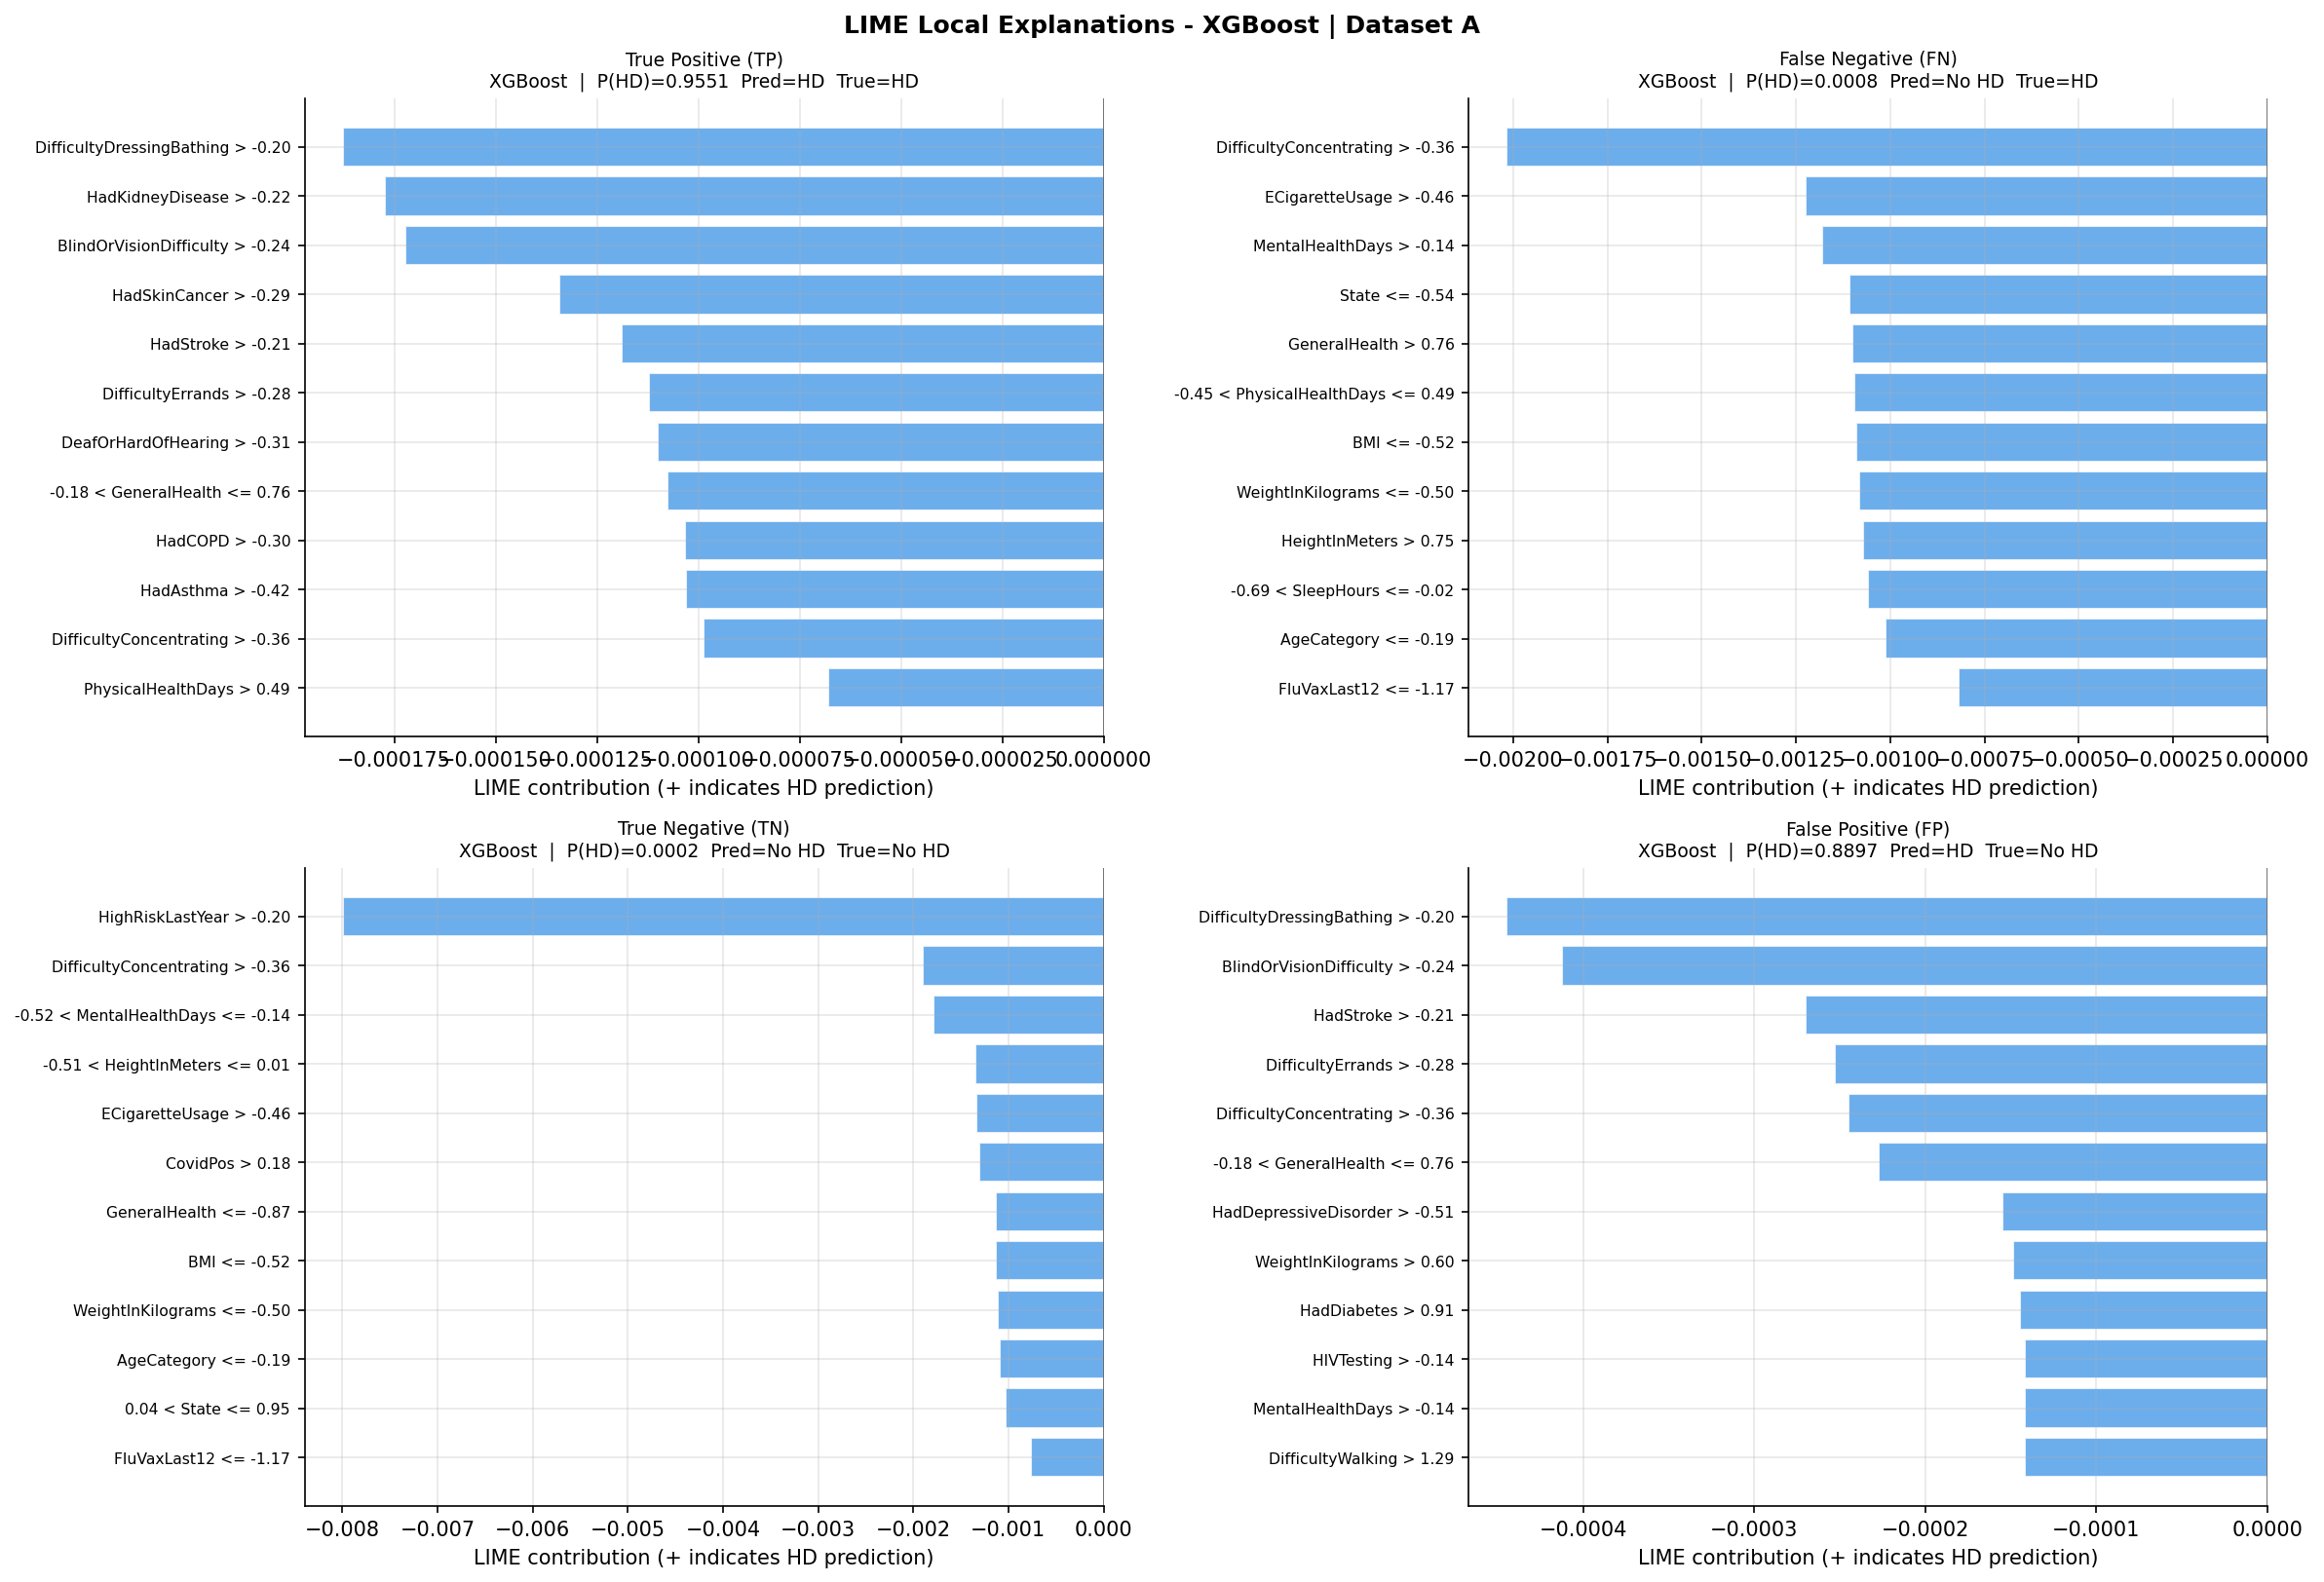

Sacuvano: figures/xai/S6_lime_A.png

LIME - XGBoost | Dataset B
True Positive (TP)         idx=   25 P(HD)=0.9995  Pred=HD True=HD
False Negative (FN)        idx=  178 P(HD)=0.0053  Pred=No HD True=HD
True Negative (TN)         idx=   26 P(HD)=0.0002  Pred=No HD True=No HD
False Positive (FP)        idx=  118 P(HD)=0.9950  Pred=HD True=No HD


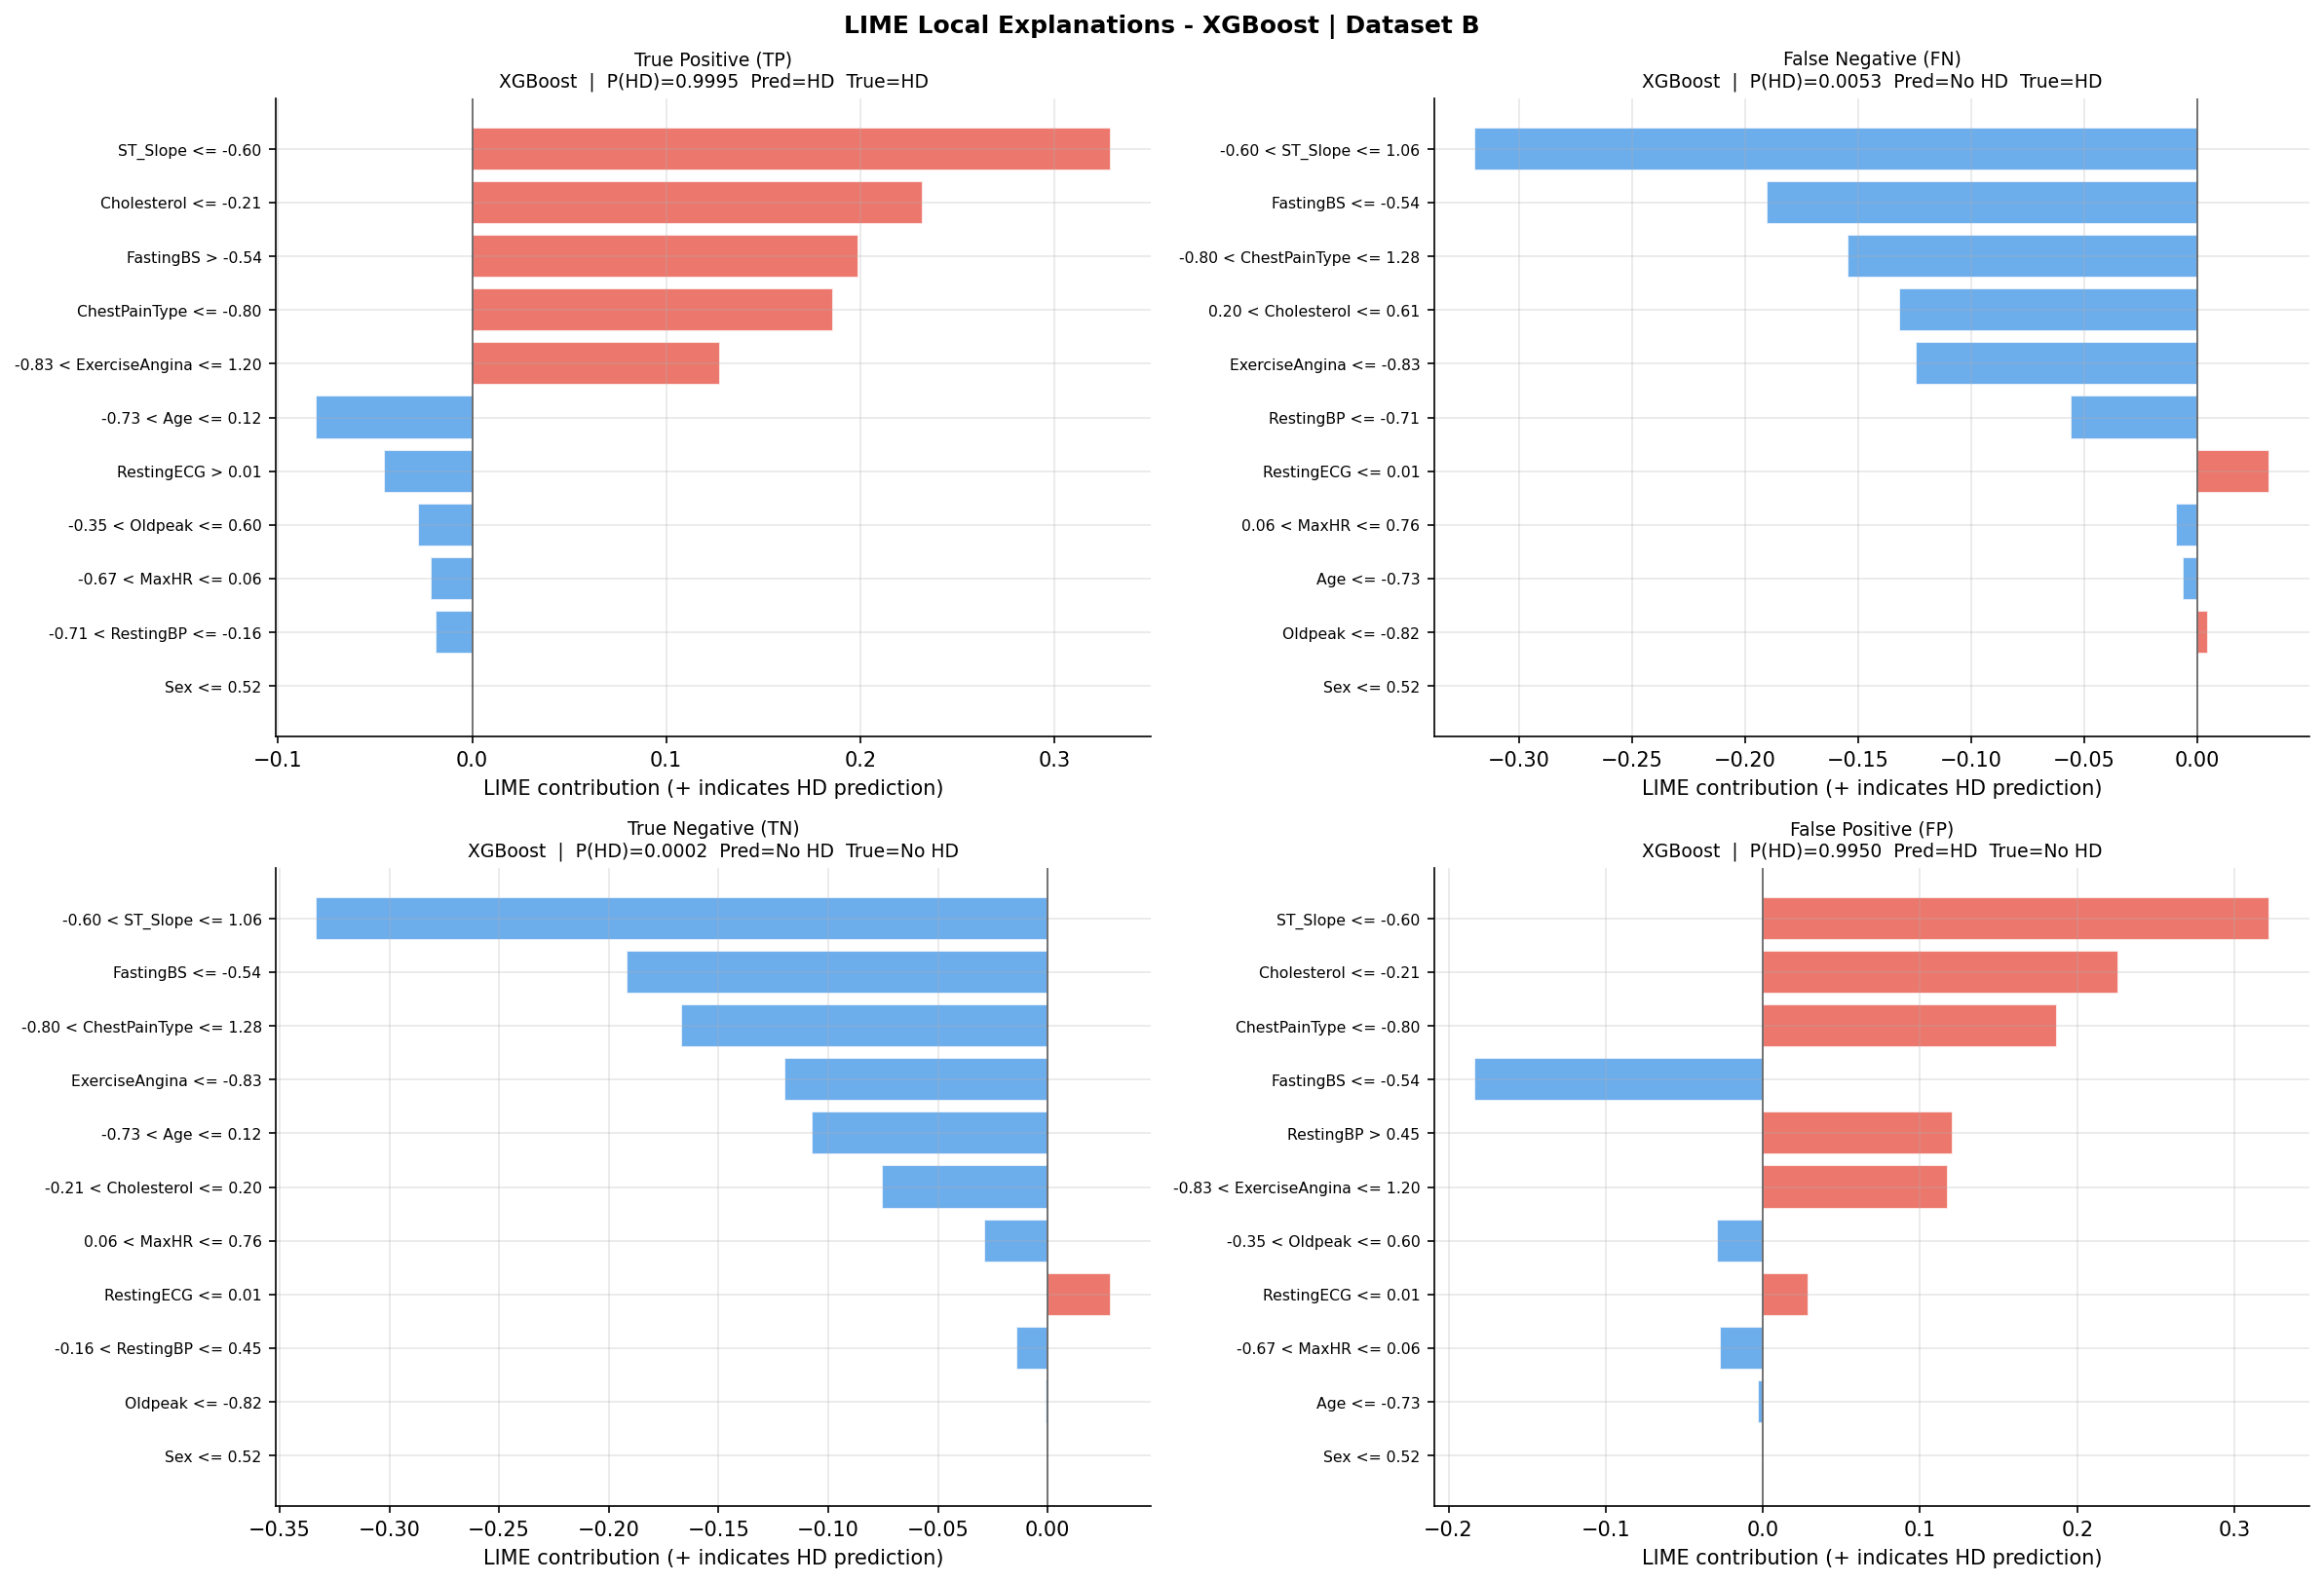

Sacuvano: figures/xai/S6_lime_B.png


In [10]:
# LIME analiza 

def lime_analysis(model, X_train_bg, X_test, y_test, feat_names,
                  model_name, ds_label, n_lime_features=12):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    lime_exp = lime_tabular.LimeTabularExplainer(
        X_train_bg,
        feature_names=feat_names,
        class_names=['No HD', 'HD'],
        mode='classification',
        random_state=SEED
    )

    # Odabir primjera
    tp = np.where((y_pred == 1) & (y_test == 1))[0]
    fn = np.where((y_pred == 0) & (y_test == 1))[0]
    tn = np.where((y_pred == 0) & (y_test == 0))[0]
    fp = np.where((y_pred == 1) & (y_test == 0))[0]

    candidates = {
        'True Positive (TP)': (tp[np.argmax(y_prob[tp])], 'HD', 'HD'),
        'False Negative (FN)': (fn[np.argmin(y_prob[fn])], 'No HD', 'HD'),
        'True Negative (TN)': (tn[np.argmin(y_prob[tn])], 'No HD', 'No HD'),
        'False Positive (FP)': (fp[np.argmax(y_prob[fp])], 'HD', 'No HD'),
    }

    # Print
    print()
    print('=' * W)
    print(f'LIME - {model_name} | {ds_label}')
    print('=' * W)
    for lbl, (i, pred_lbl, true_lbl) in candidates.items():
        print(f'{lbl:<26} idx={i:>5} P(HD)={y_prob[i]:.4f}  '
              f'Pred={pred_lbl} True={true_lbl}')
    print('=' * W)

    # Vizualizacija
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    axes = axes.flatten()

    for ax, (lbl, (i, pred_lbl, true_lbl)) in zip(axes, candidates.items()):
        exp = lime_exp.explain_instance(
            X_test[i], model.predict_proba,
            num_features=n_lime_features, labels=[1]
        )
        lime_list = sorted(exp.as_list(label=1), key=lambda x: abs(x[1]))
        f_labels = [f[0][:40] for f in lime_list]
        f_vals = [f[1] for f in lime_list]
        colors = [CLR_POS if v > 0 else CLR_NEG for v in f_vals]

        ax.barh(f_labels, f_vals, color=colors, alpha=0.82, edgecolor='white')
        ax.axvline(0, color='black', lw=0.8, alpha=0.6)
        ax.set_title(
            f'{lbl}\n{model_name}  |  P(HD)={y_prob[i]:.4f}  '
            f'Pred={pred_lbl}  True={true_lbl}',
            fontsize=9
        )
        ax.set_xlabel('LIME contribution (+ indicates HD prediction)')
        ax.tick_params(axis='y', labelsize=7.5)

    plt.suptitle(f'LIME Local Explanations - {model_name} | {ds_label}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    ds_key = 'A' if 'A' in ds_label else 'B'
    fname = f'figures/xai/S6_lime_{ds_key}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Sacuvano: {fname}')


# Background za LIME: subsample trening podataka
bg_lime_a = X_a_train[np.random.choice(len(X_a_train), 500, replace=False)]
bg_lime_b = X_b_train

lime_analysis(
    all_models_a[BEST_MODEL_NAME], bg_lime_a, X_a_test, y_a_test,
    feature_names_a, BEST_MODEL_NAME, 'Dataset A'
)
lime_analysis(
    all_models_b[BEST_MODEL_NAME], bg_lime_b, X_b_test, y_b_test,
    feature_names_b, BEST_MODEL_NAME, 'Dataset B'
)

## 3. Permutation Feature Importance (PFI)

PFI mjeri koliko se performanse modela pogoršaju kada se nasumično promijene vrijednosti jednog featura. Ako performanse značajno padnu, taj feature je važan za model. Za razliku od Gini importance, PFI se može koristiti na različitim modelima i računa se na test skupu. Ponavljanje više puta (`n_repeats`) pokazuje stabilnost rezultata.


In [11]:
# PFI za top modele 

PFI_MODELS = [BEST_MODEL_NAME, 'Logistic Regression']
N_REPEATS = 10
pfi_results = {}

for ds_key, X_te, y_te, feat_names, ds_lbl, model_dict in [
    ('A', X_a_test, y_a_test, feature_names_a, 'Dataset A', all_models_a),
    ('B', X_b_test, y_b_test, feature_names_b, 'Dataset B', all_models_b),
]:
    for mname in PFI_MODELS:
        if mname not in model_dict:
            continue
        model = model_dict[mname]
        print(f'PFI: {mname} | {ds_lbl} ({N_REPEATS} ponavljanja)...', end=' ', flush=True)
        t0 = time.time()
        result = permutation_importance(
            model, X_te, y_te,
            n_repeats=N_REPEATS,
            random_state=SEED,
            n_jobs=-1,
            scoring='roc_auc'
        )
        print(f'{time.time()-t0:.1f}s')
        pfi_results[f'{mname}_{ds_key}'] = {
            'importances_mean': result.importances_mean,
            'importances_std': result.importances_std,
            'importances': result.importances,
            'feature_names': feat_names,
            'model': mname, 'dataset': ds_lbl
        }

# Ispis PFI tabele 
TOP_PFI = 10
for key, res in pfi_results.items():
    idx = np.argsort(res['importances_mean'])[::-1][:TOP_PFI]
    print()
    print('=' * W)
    print(f'PFI Top-{TOP_PFI} | {res["model"]} | {res["dataset"]}')
    print(f'Scoring: ROC-AUC | n_repeats={N_REPEATS}')
    print('=' * W)
    print(f'{"Rank":<5} {"Feature":<36} {"Mean drop":>10} {"Std":>8}')
    print('-' * W)
    for rank, i in enumerate(idx, 1):
        print(f'{rank:<5} {res["feature_names"][i]:<36} '
              f'{res["importances_mean"][i]:>10.5f}  '
              f'{res["importances_std"][i]:>8.5f}')
    print('=' * W)

PFI: XGBoost | Dataset A (10 ponavljanja)... 61.3s
PFI: Logistic Regression | Dataset A (10 ponavljanja)... 5.5s
PFI: XGBoost | Dataset B (10 ponavljanja)... 0.3s
PFI: Logistic Regression | Dataset B (10 ponavljanja)... 0.1s

PFI Top-10 | XGBoost | Dataset A
Scoring: ROC-AUC | n_repeats=10
Rank  Feature                               Mean drop      Std
------------------------------------------------------------------
1     HadAngina                               0.07543   0.00115
2     AgeCategory                             0.03303   0.00135
3     Sex                                     0.01109   0.00072
4     GeneralHealth                           0.00904   0.00084
5     ChestScan                               0.00760   0.00037
6     HadStroke                               0.00708   0.00031
7     RemovedTeeth                            0.00315   0.00021
8     SmokerStatus                            0.00212   0.00030
9     HadDiabetes                             0.00183   0.00027
10 

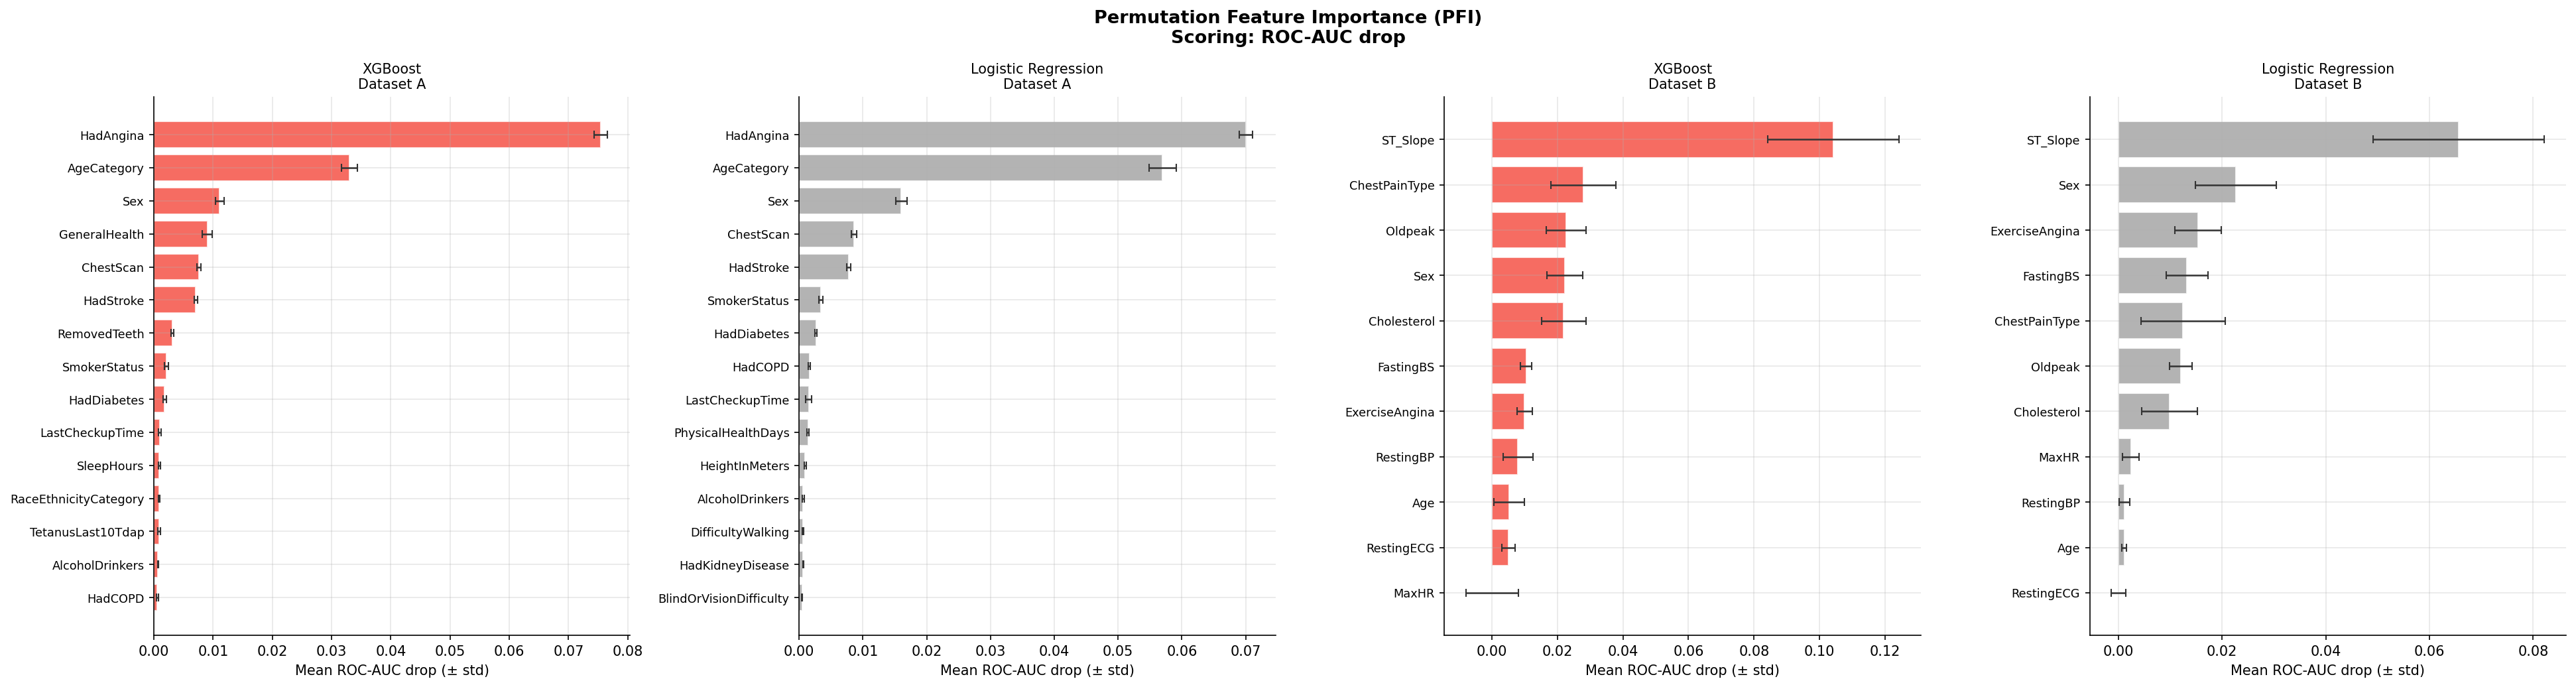

Sacuvano: figures/xai/S6_pfi.png


In [12]:
# PFI Vizualizacije 

n_plots = len(pfi_results)
fig, axes = plt.subplots(1, n_plots, figsize=(6.5 * n_plots, 7))
if n_plots == 1:
    axes = [axes]

for ax, (key, res) in zip(axes, pfi_results.items()):
    top_n = min(15, len(res['feature_names']))
    idx = np.argsort(res['importances_mean'])[::-1][:top_n]
    means = res['importances_mean'][idx]
    stds = res['importances_std'][idx]
    feats = [res['feature_names'][i] for i in idx]
    color = MODEL_COLORS_XAI.get(res['model'], '#607D8B')

    ax.barh(range(top_n), means[::-1], xerr=stds[::-1],
            color=color, alpha=0.78, edgecolor='white',
            error_kw=dict(ecolor='#333', lw=1.2, capsize=3))
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(feats[::-1], fontsize=8.5)
    ax.set_xlabel('Mean ROC-AUC drop (± std)')
    ax.set_title(f'{res["model"]}\n{res["dataset"]}', fontsize=10)

plt.suptitle('Permutation Feature Importance (PFI)\nScoring: ROC-AUC drop',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/xai/S6_pfi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/xai/S6_pfi.png')

In [13]:
# Cross-method konzistentnost: SHAP vs PFI 

for ds_key, ds_lbl in [('A', 'Dataset A'), ('B', 'Dataset B')]:
    key_pfi = f'{BEST_MODEL_NAME}_{ds_key}'
    if key_pfi not in pfi_results:
        continue
    if BEST_MODEL_NAME not in (shap_values_a if ds_key == 'A' else shap_values_b):
        continue

    shap_dict = shap_values_a if ds_key == 'A' else shap_values_b
    feat_names = feature_names_a if ds_key == 'A' else feature_names_b
    sv = shap_dict[BEST_MODEL_NAME]
    res = pfi_results[key_pfi]

    shap_rank = np.argsort(np.abs(sv).mean(axis=0))[::-1]
    pfi_rank = np.argsort(res['importances_mean'])[::-1]

    TOP = min(15, len(feat_names))
    shap_top = set(shap_rank[:TOP])
    pfi_top = set(pfi_rank[:TOP])
    overlap = shap_top & pfi_top
    jaccard = len(overlap) / len(shap_top | pfi_top)

    corr, pval = spearmanr(
        [list(shap_rank).index(i) for i in range(len(feat_names))],
        [list(pfi_rank).index(i) for i in range(len(feat_names))]
    )

    print()
    print('=' * W)
    print(f'SHAP vs PFI konzistentnost | {BEST_MODEL_NAME} | {ds_lbl}')
    print('=' * W)
    print(f'Top-{TOP} Jaccard similarity: {jaccard:.4f}')
    print(f'Spearman rang-korelacija: {corr:.4f} (p={pval:.4f})')
    print(f'Zajednicki featurei u top-{TOP}: {len(overlap)}/{TOP}')
    print('-' * W)
    print(f'Zajednicki: {sorted([feat_names[i] for i in overlap])}')
    print('=' * W)


SHAP vs PFI konzistentnost | XGBoost | Dataset A
Top-15 Jaccard similarity: 0.6667
Spearman rang-korelacija: 0.8506 (p=0.0000)
Zajednicki featurei u top-15: 12/15
------------------------------------------------------------------
Zajednicki: ['AgeCategory', 'AlcoholDrinkers', 'ChestScan', 'GeneralHealth', 'HadAngina', 'HadDiabetes', 'HadStroke', 'RemovedTeeth', 'Sex', 'SleepHours', 'SmokerStatus', 'TetanusLast10Tdap']

SHAP vs PFI konzistentnost | XGBoost | Dataset B
Top-11 Jaccard similarity: 1.0000
Spearman rang-korelacija: 0.8182 (p=0.0021)
Zajednicki featurei u top-11: 11/11
------------------------------------------------------------------
Zajednicki: ['Age', 'ChestPainType', 'Cholesterol', 'ExerciseAngina', 'FastingBS', 'MaxHR', 'Oldpeak', 'RestingBP', 'RestingECG', 'ST_Slope', 'Sex']


## 4. Stabilnost objašnjenja

Pokretamo SHAP analizu kroz 5 različitih random seed-ova modela kako bismo provjerili da li model s različitim random inicijalizacijama identificira iste feature-e kao najvažnije. Ovo direktno odgovara na istraživačko pitanje: **"Da li su XAI objašnjenja stabilna i klinički pouzdana?"**

Metrike stabilnosti:
- **Jaccard@K**: udio preklapanja top-K featura između parova seed-ova
- **Spearman ρ**: korelacija rang-lista između parova seed-ova
- **Rank variance**: varijansa ranga svakog featura kroz svih 5 seed-ova

In [14]:
# Stabilnost: 5 seed-ova × best model × oba dataseta 

STABILITY_SEEDS = [42, 43, 44, 45, 46]
K_STAB = 10

def get_model_config(model_name):
    """Vraca konfiguraciju modela iz S5 za dati naziv."""
    if 'XGBoost' in model_name:
        return XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=3, gamma=0.1,
            reg_alpha=0.1, reg_lambda=1.0,
            tree_method='hist', eval_metric='logloss',
            n_jobs=-1, verbosity=0
        )
    elif 'LightGBM' in model_name:
        return LGBMClassifier(
            n_estimators=300, num_leaves=63, max_depth=7,
            learning_rate=0.05, min_child_samples=30,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=0.1,
            n_jobs=-1, verbose=-1
        )
    elif 'CatBoost' in model_name:
        return CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.05,
            l2_leaf_reg=3, border_count=64,
            task_type='CPU', verbose=0
        )
    elif 'Random Forest' in model_name:
        return RandomForestClassifier(
            n_estimators=100, max_features='sqrt', max_depth=20,
            min_samples_split=10, min_samples_leaf=5, n_jobs=-1
        )
    elif 'Logistic' in model_name:
        return LogisticRegression(
            C=1.0, solver='saga', max_iter=1000, n_jobs=-1
        )
    raise ValueError(f'Nepoznati model: {model_name}')


stability_data = {}  # {ds_key: {seed: shap_rank_vector}}

for ds_key, X_tr, y_tr, X_te, y_te, feat_names, ds_lbl in [
    ('A', X_a_train, y_a_train, X_a_test, y_a_test, feature_names_a, 'Dataset A'),
    ('B', X_b_train, y_b_train, X_b_test, y_b_test, feature_names_b, 'Dataset B'),
]:
    print(f'\nStabilnost: {BEST_MODEL_NAME} | {ds_lbl}')
    print('-' * W)
    seed_rankings = []
    seed_shap_means = []

    for seed in STABILITY_SEEDS:
        print(f'  Seed {seed}...', end=' ', flush=True)
        t0 = time.time()
        clf = get_model_config(BEST_MODEL_NAME)
        clf.set_params(random_state=seed) if hasattr(clf, 'set_params') else None
        if hasattr(clf, 'random_seed'):
            clf.set_params(random_seed=seed)
        clf.fit(X_tr, y_tr)

        X_shap_sub = X_te[rng.choice(len(X_te), min(1000, len(X_te)), replace=False)]
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(X_shap_sub, check_additivity=False)
        if isinstance(sv, list):
            sv = sv[1]
        if sv.ndim == 3:
            sv = sv[:, :, 1]

        mean_abs = np.abs(sv).mean(axis=0)
        ranking = np.argsort(mean_abs)[::-1]
        seed_rankings.append(ranking)
        seed_shap_means.append(mean_abs)
        print(f'{time.time()-t0:.1f}s | top-3: {[feat_names[i] for i in ranking[:3]]}')

    stability_data[ds_key] = {
        'seed_rankings': seed_rankings,
        'seed_shap_means': seed_shap_means,
        'feat_names': feat_names,
        'ds_label': ds_lbl
    }


Stabilnost: XGBoost | Dataset A
------------------------------------------------------------------
  Seed 42... 16.2s | top-3: ['HadAngina', 'AgeCategory', 'GeneralHealth']
  Seed 43... 16.2s | top-3: ['HadAngina', 'AgeCategory', 'GeneralHealth']
  Seed 44... 19.3s | top-3: ['HadAngina', 'AgeCategory', 'SleepHours']
  Seed 45... 21.5s | top-3: ['HadAngina', 'AgeCategory', 'GeneralHealth']
  Seed 46... 22.1s | top-3: ['HadAngina', 'AgeCategory', 'GeneralHealth']

Stabilnost: XGBoost | Dataset B
------------------------------------------------------------------
  Seed 42... 0.3s | top-3: ['ST_Slope', 'ChestPainType', 'Cholesterol']
  Seed 43... 0.3s | top-3: ['ST_Slope', 'ChestPainType', 'Cholesterol']
  Seed 44... 0.3s | top-3: ['ST_Slope', 'ChestPainType', 'Cholesterol']
  Seed 45... 0.3s | top-3: ['ST_Slope', 'ChestPainType', 'Cholesterol']
  Seed 46... 0.3s | top-3: ['ST_Slope', 'ChestPainType', 'Cholesterol']


In [15]:
# Stabilnost - metrike i ispis 

for ds_key, sd in stability_data.items():
    rankings = sd['seed_rankings']
    shap_means = sd['seed_shap_means']
    feat_names = sd['feat_names']
    ds_lbl = sd['ds_label']
    n_seeds = len(rankings)

    # Jaccard@K matrica
    jac_matrix = np.zeros((n_seeds, n_seeds))
    cor_matrix = np.zeros((n_seeds, n_seeds))
    for i in range(n_seeds):
        for j in range(n_seeds):
            top_i = set(rankings[i][:K_STAB])
            top_j = set(rankings[j][:K_STAB])
            jac_matrix[i, j] = len(top_i & top_j) / len(top_i | top_j)
            rank_i = [list(rankings[i]).index(k) for k in range(len(feat_names))]
            rank_j = [list(rankings[j]).index(k) for k in range(len(feat_names))]
            cor_matrix[i, j], _ = spearmanr(rank_i, rank_j)

    # Rank varijabilnost
    rank_matrix = np.zeros((n_seeds, len(feat_names)))
    for i, r in enumerate(rankings):
        for pos, feat_idx in enumerate(r):
            rank_matrix[i, feat_idx] = pos + 1
    rank_std = rank_matrix.std(axis=0)
    stable_feats = np.argsort(rank_std)[:K_STAB]

    mean_jac = jac_matrix[np.triu_indices(n_seeds, k=1)].mean()
    mean_cor = cor_matrix[np.triu_indices(n_seeds, k=1)].mean()

    print()
    print('=' * W)
    print(f'Stabilnost objasnjenja | {BEST_MODEL_NAME} | {ds_lbl}')
    print(f'{n_seeds} seed-ova: {STABILITY_SEEDS}')
    print('=' * W)
    print(f'Mean Jaccard@{K_STAB}: {mean_jac:.4f}  '
          f'(1.0 = perfektno poklapanje)')
    print(f'Mean Spearman korelacija: {mean_cor:.4f}  '
          f'(1.0 = isti poredak)')
    print()
    print(f'Najstabilniji featurei (najniza varijansa ranga):')
    print(f'{"Rank":<5} {"Feature":<36} {"Mean rank":>10} {"Std":>8}')
    print('-' * W)
    for rank, i in enumerate(stable_feats, 1):
        print(f'{rank:<5} {feat_names[i]:<36} '
              f'{rank_matrix[:, i].mean():>10.2f}  '
              f'{rank_std[i]:>8.3f}')
    print('=' * W)

    sd['jac_matrix'] = jac_matrix
    sd['cor_matrix'] = cor_matrix
    sd['rank_std'] = rank_std
    sd['rank_matrix'] = rank_matrix


Stabilnost objasnjenja | XGBoost | Dataset A
5 seed-ova: [42, 43, 44, 45, 46]
Mean Jaccard@10: 0.8909  (1.0 = perfektno poklapanje)
Mean Spearman korelacija: 0.9917  (1.0 = isti poredak)

Najstabilniji featurei (najniza varijansa ranga):
Rank  Feature                               Mean rank      Std
------------------------------------------------------------------
1     HadAngina                                  1.00     0.000
2     RemovedTeeth                               5.00     0.000
3     SmokerStatus                               8.00     0.000
4     AgeCategory                                2.00     0.000
5     TetanusLast10Tdap                          9.00     0.000
6     HighRiskLastYear                          39.00     0.000
7     GeneralHealth                              3.20     0.400
8     SleepHours                                 3.80     0.400
9     FluVaxLast12                              16.80     0.400
10    HadAsthma                                 32.80  

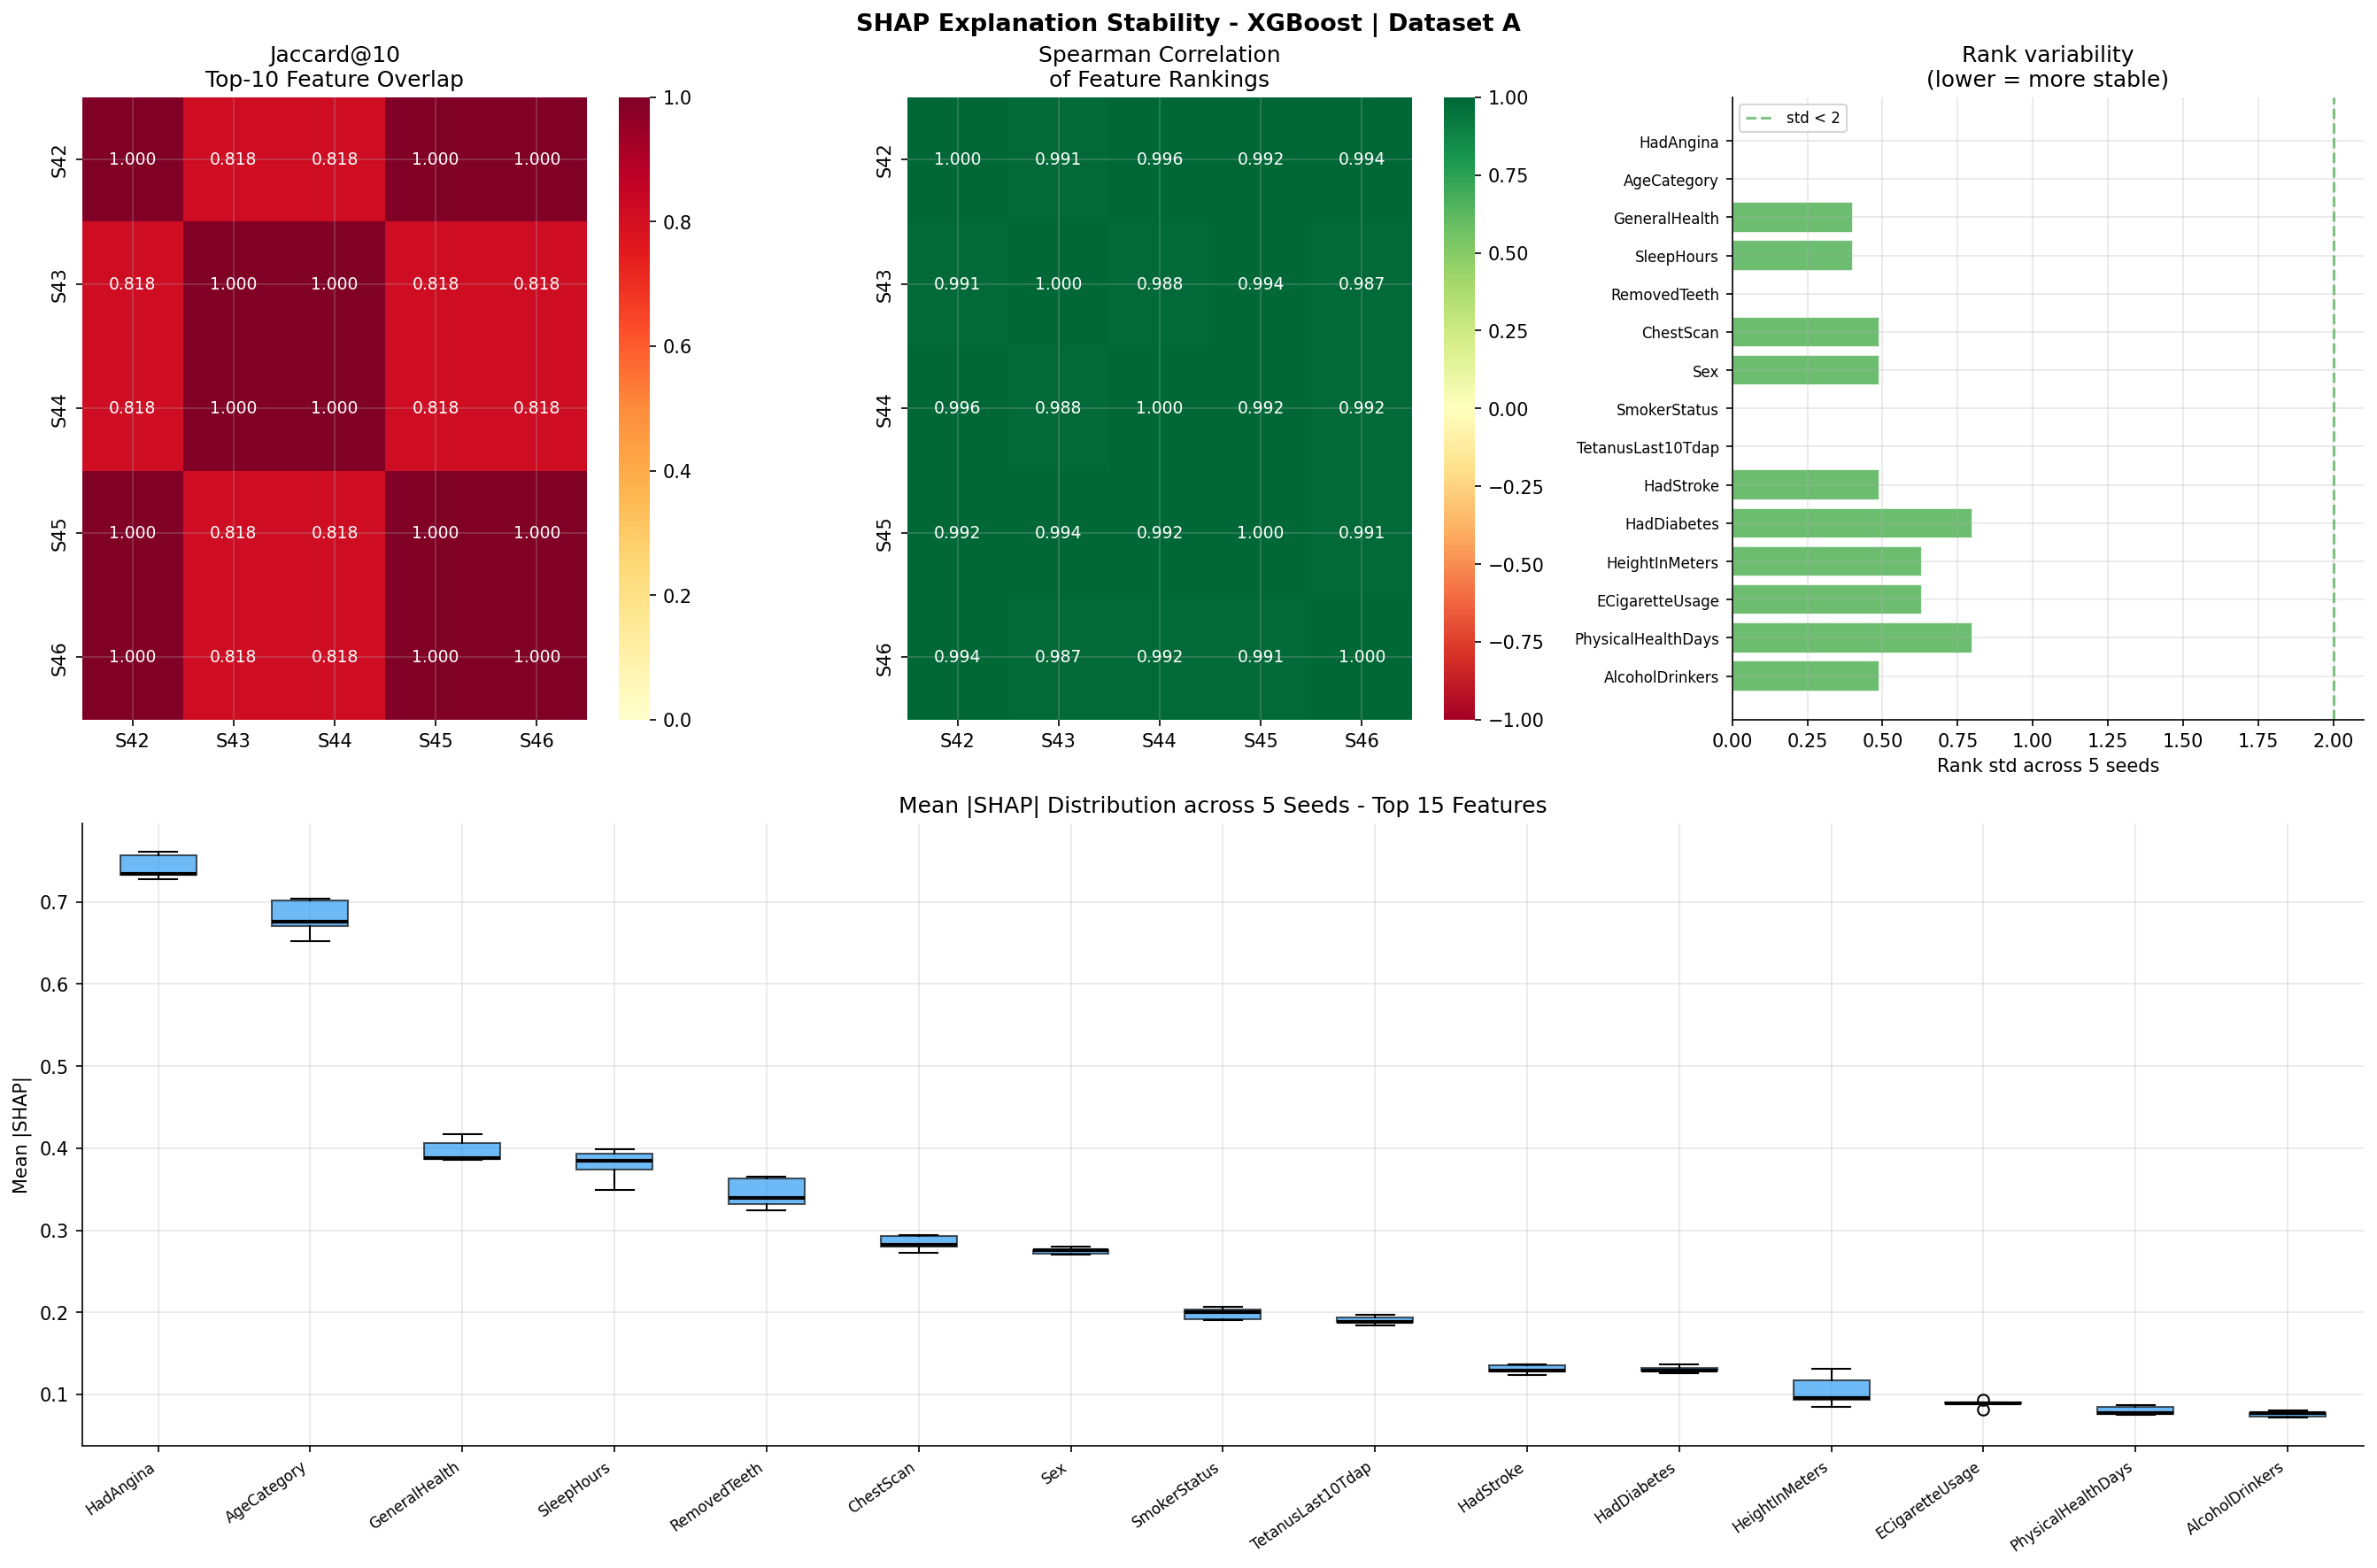

Sacuvano: figures/xai/S6_stability_A.png


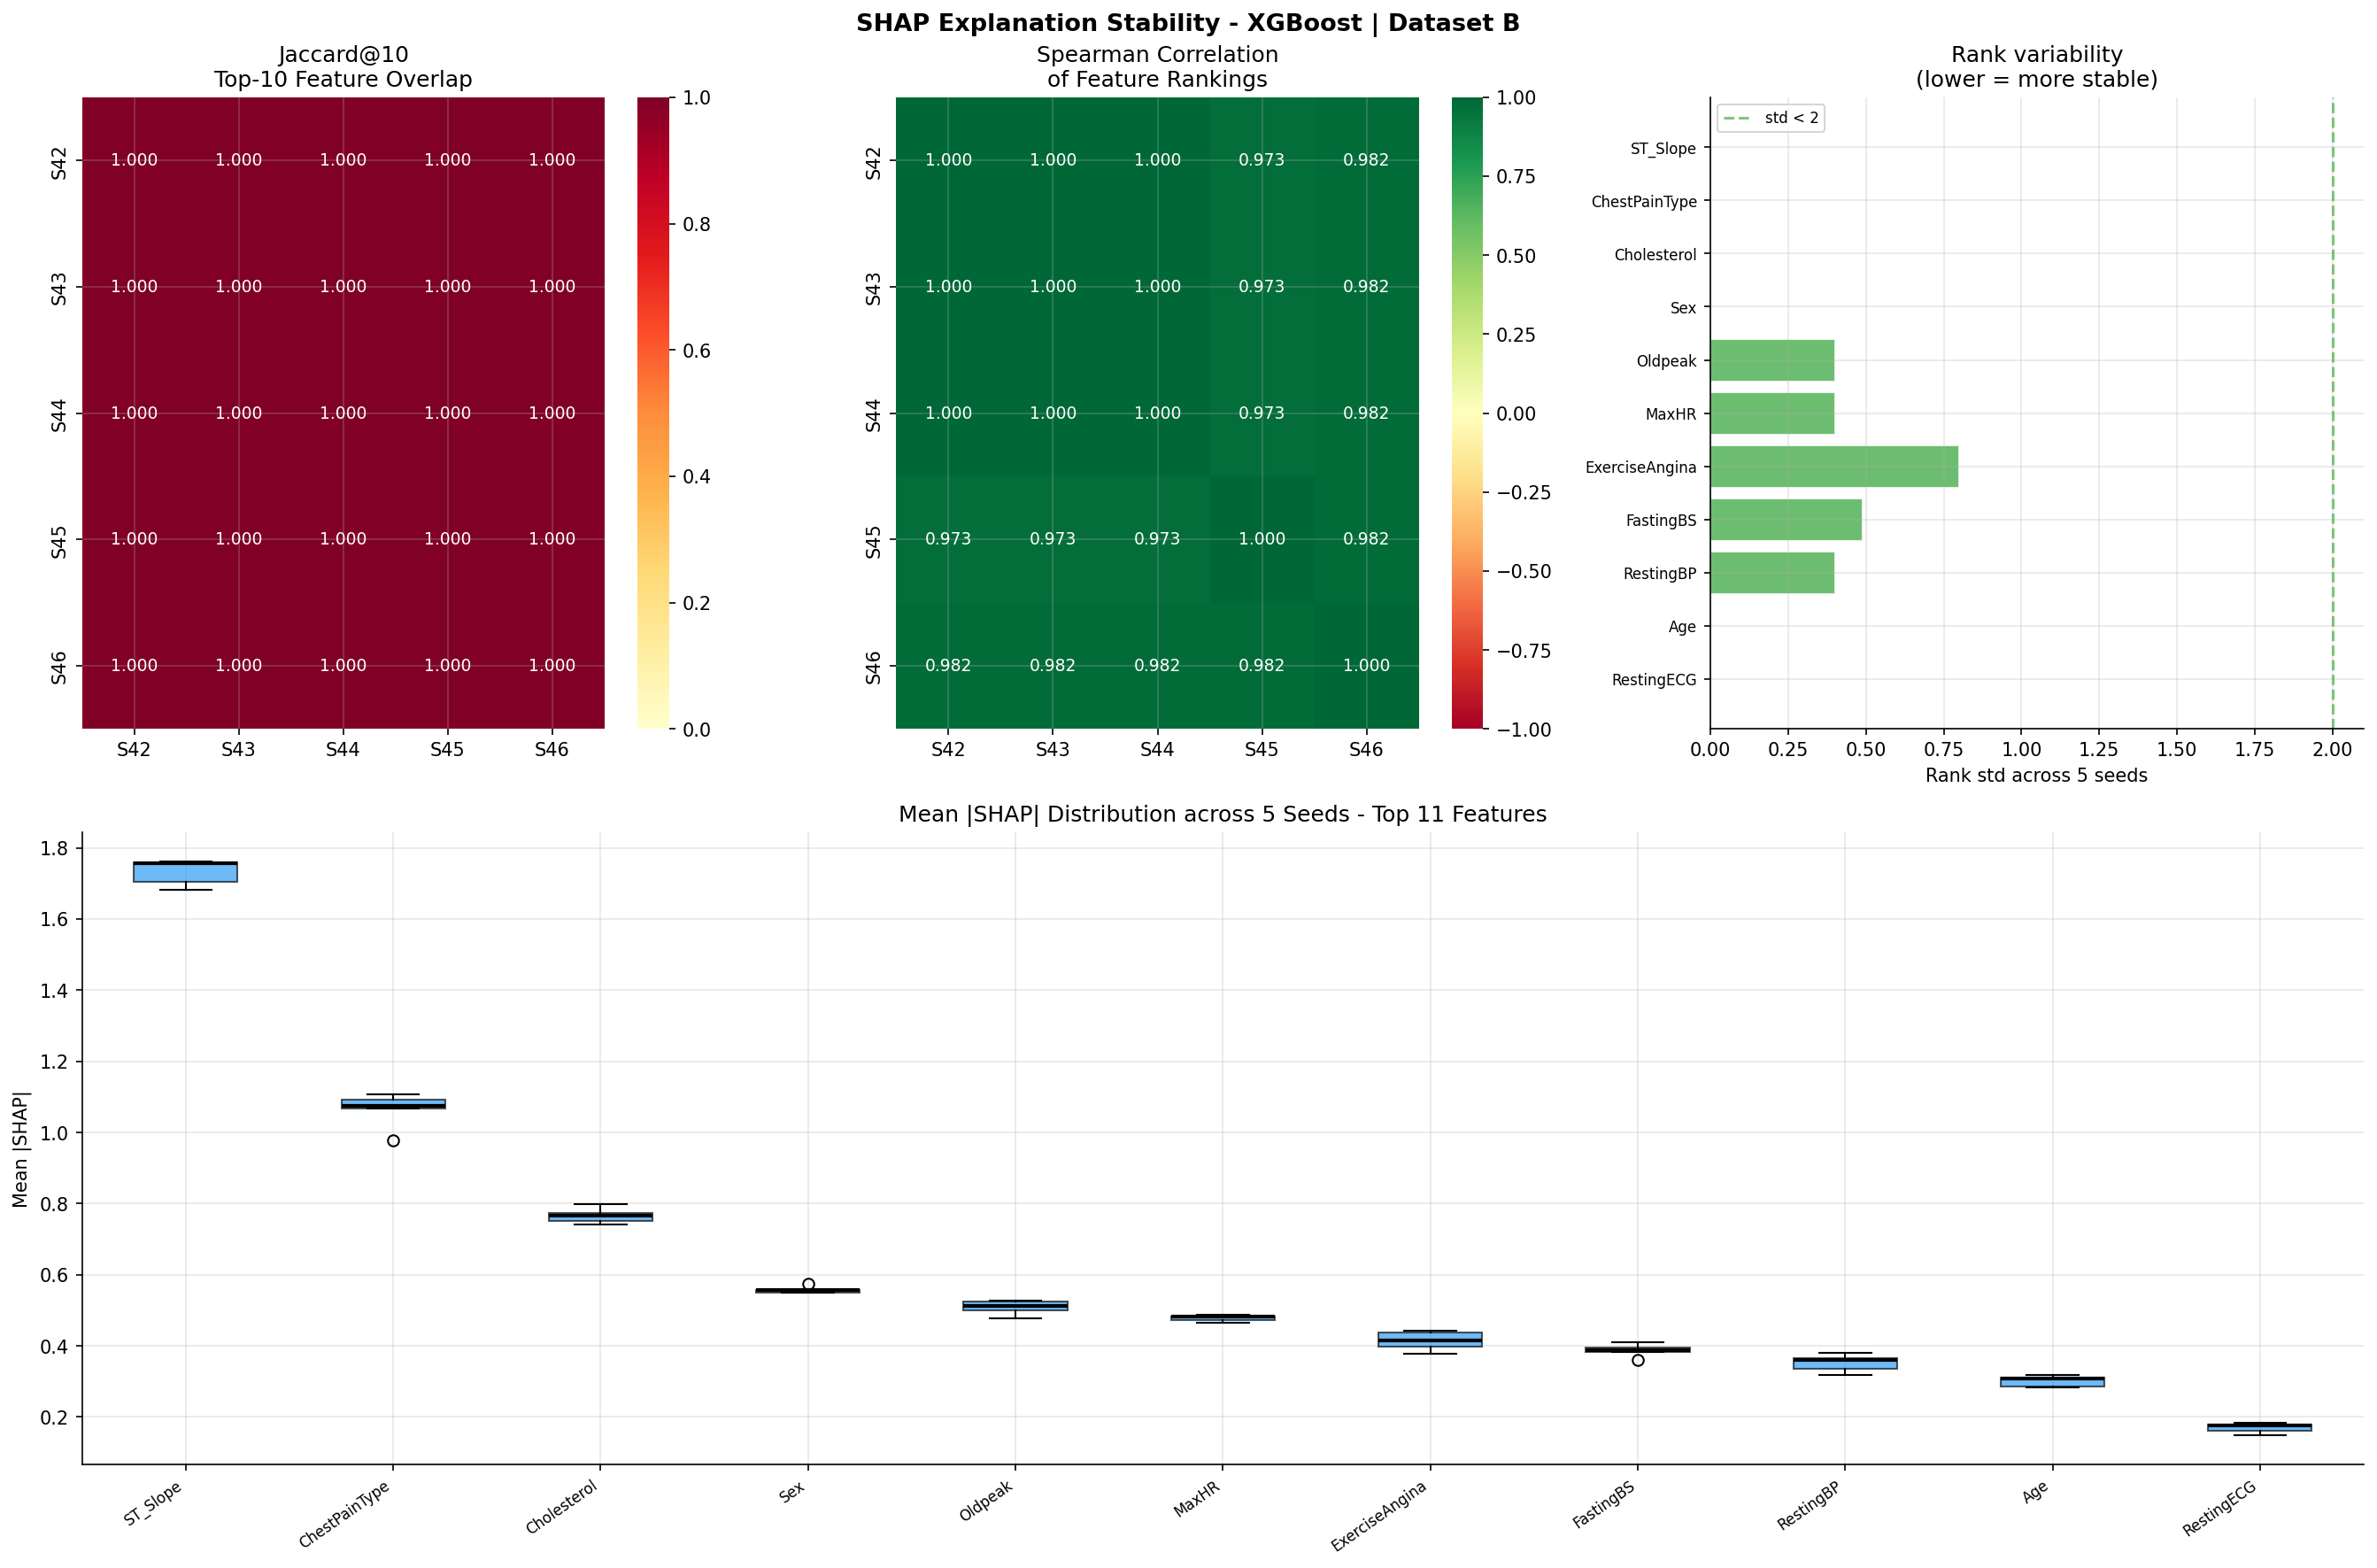

Sacuvano: figures/xai/S6_stability_B.png


In [16]:
# Stabilnost - vizualizacije 

for ds_key, sd in stability_data.items():
    feat_names = sd['feat_names']
    shap_means = np.array(sd['seed_shap_means'])
    top_n = min(15, len(feat_names))
    top_idx = np.argsort(shap_means.mean(axis=0))[::-1][:top_n]
    top_feats = [feat_names[i] for i in top_idx]

    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(2, 3, figure=fig)

    # 1. Jaccard heatmap
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(sd['jac_matrix'], annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[f'S{s}' for s in STABILITY_SEEDS],
                yticklabels=[f'S{s}' for s in STABILITY_SEEDS],
                ax=ax1, vmin=0, vmax=1, annot_kws={'size': 9})
    ax1.set_title(f'Jaccard@{K_STAB}\nTop-{K_STAB} Feature Overlap')

    # 2. Spearman heatmap
    ax2 = fig.add_subplot(gs[0, 1])
    sns.heatmap(sd['cor_matrix'], annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=[f'S{s}' for s in STABILITY_SEEDS],
                yticklabels=[f'S{s}' for s in STABILITY_SEEDS],
                ax=ax2, vmin=-1, vmax=1, annot_kws={'size': 9})
    ax2.set_title('Spearman Correlation\nof Feature Rankings')

    # 3. Rank variance bar
    ax3 = fig.add_subplot(gs[0, 2])
    top15_std = sd['rank_std'][top_idx]
    colors_stb = ['#4CAF50' if v < 2 else '#FF9800' if v < 4 else '#F44336' for v in top15_std]
    ax3.barh(range(top_n), top15_std[::-1], color=colors_stb[::-1], alpha=0.82, edgecolor='white')
    ax3.set_yticks(range(top_n))
    ax3.set_yticklabels(top_feats[::-1], fontsize=8)
    ax3.set_xlabel('Rank std across 5 seeds')
    ax3.set_title('Rank variability\n(lower = more stable)')
    ax3.axvline(x=2, color='#4CAF50', lw=1.5, linestyle='--', alpha=0.7, label='std < 2')
    ax3.legend(fontsize=8)

    # 4. Box plots mean|SHAP| po seed-u
    ax4 = fig.add_subplot(gs[1, :])
    data_box = [shap_means[:, i] for i in top_idx]
    bp = ax4.boxplot(data_box, vert=True, patch_artist=True,
                     medianprops={'color': 'black', 'lw': 2})
    for patch in bp['boxes']:
        patch.set_facecolor('#2196F3')
        patch.set_alpha(0.65)
    ax4.set_xticks(range(1, top_n + 1))
    ax4.set_xticklabels(top_feats, rotation=35, ha='right', fontsize=8)
    ax4.set_ylabel('Mean |SHAP|')
    ax4.set_title(f'Mean |SHAP| Distribution across 5 Seeds - Top {top_n} Features')

    ds_lbl = sd['ds_label']
    plt.suptitle(
        f'SHAP Explanation Stability - {BEST_MODEL_NAME} | {ds_lbl}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    fname = f'figures/xai/S6_stability_{ds_key}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Sacuvano: {fname}')

## 4b. Stabilnost kroz različite TRAIN/TEST PODJELE

Ovo je **ključni doprinos rada**. Za razliku od sekcije 4a (isti podaci, različiti seed-ovi modela), ovdje ponavljamo **cijeli pipeline** - od podjele podataka do SHAP analize - kroz 5 nezavisnih 80/20 podjela. Ovo direktno odgovara na istraživačko pitanje:

> *"Da li su ta objašnjenja stabilna kroz različite podjele podataka ili različita ponavljanja eksperimenta?"*

**Metodologija po svakoj podjeli:** nova 80/20 podjela originalnih podataka -> preprocessing (encoding, scaling fit isključivo na train) -> SMOTE na train skupu -> treniranje modela -> SHAP na test skupu -> usporedba top-K rankinga.

In [17]:
# Stabilnost kroz različite train/test PODJELE 

SPLIT_SEEDS = [42, 43, 44, 45, 46]
K_SPLIT = 10


def preprocess_split(df_raw, target_col, seed, apply_smote=True):
    """
    Replicira S3 preprocessing za jedan seed.
    Vraca (X_tr, X_te, y_tr, y_te, feat_cols).
    """
    df = df_raw.copy().drop_duplicates()
    for col in df.select_dtypes(include='number').columns:
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].fillna(df[col].mode()[0])
    if df[target_col].dtype == object:
        df[target_col] = df[target_col].map({'Yes': 1, 'No': 0})
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    if cat_cols:
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        df[cat_cols] = oe.fit_transform(df[cat_cols])
    feat_cols = [c for c in df.columns if c != target_col]
    X = df[feat_cols].values
    y = df[target_col].values
    X_tr, X_te, y_tr, y_te = tts(X, y, test_size=0.2, stratify=y, random_state=seed)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    if apply_smote:
        ratio = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        if ratio > 1.5:
            X_tr, y_tr = SMOTE(random_state=seed).fit_resample(X_tr, y_tr)
    return X_tr, X_te, y_tr, y_te, feat_cols


split_stability = {}

for ds_key, csv_path, target_col, ds_lbl in [
    ('A', '2022/heart_2022_with_nans.csv', 'HadHeartAttack', 'Dataset A'),
    ('B', 'heart.csv', 'HeartDisease', 'Dataset B'),
]:
    if not os.path.exists(csv_path):
        print(f'UPOZORENJE: {csv_path} nije pronadjen. Preskacem {ds_lbl}.')
        continue

    print(f'\nStabilnost kroz podjele: {BEST_MODEL_NAME} | {ds_lbl}')
    print('-' * W)
    df_raw = pd.read_csv(csv_path)
    split_rankings, split_shap_means = [], []

    for seed in SPLIT_SEEDS:
        print(f'Podjela seed={seed}...', end=' ', flush=True)
        t0 = time.time()
        X_tr, X_te, y_tr, y_te, feat_cols = preprocess_split(
            df_raw, target_col, seed, apply_smote=(ds_key == 'A')
        )
        clf = get_model_config(BEST_MODEL_NAME)
        if hasattr(clf, 'set_params'):
            clf.set_params(random_state=seed)
        if hasattr(clf, 'random_seed'):
            clf.set_params(random_seed=seed)
        clf.fit(X_tr, y_tr)

        n_s = min(1500, len(X_te))
        X_sub = X_te[np.random.RandomState(seed).choice(len(X_te), n_s, replace=False)]
        sv = shap.TreeExplainer(clf).shap_values(X_sub, check_additivity=False)
        if isinstance(sv, list): sv = sv[1]
        if sv.ndim == 3: sv = sv[:, :, 1]

        mean_abs = np.abs(sv).mean(axis=0)
        ranking = np.argsort(mean_abs)[::-1]
        split_rankings.append(ranking)
        split_shap_means.append(mean_abs)
        top3 = [feat_cols[i] for i in ranking[:3]]
        print(f'{time.time()-t0:.1f}s train={X_tr.shape[0]:,} test={X_te.shape[0]:,} top3={top3}')

    n = len(SPLIT_SEEDS)
    n_feats = len(feat_cols)
    jac_mat = np.zeros((n, n))
    cor_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ti = set(split_rankings[i][:K_SPLIT])
            tj = set(split_rankings[j][:K_SPLIT])
            jac_mat[i, j] = len(ti & tj) / len(ti | tj)
            ri = [list(split_rankings[i]).index(k) for k in range(n_feats)]
            rj = [list(split_rankings[j]).index(k) for k in range(n_feats)]
            cor_mat[i, j], _ = spearmanr(ri, rj)

    rank_mat = np.zeros((n, n_feats))
    for i, r in enumerate(split_rankings):
        for pos, fi in enumerate(r): rank_mat[i, fi] = pos + 1

    mean_jac = jac_mat[np.triu_indices(n, k=1)].mean()
    mean_cor = cor_mat[np.triu_indices(n, k=1)].mean()

    # Featurei u top-K u svim podjelama
    always_top = set.intersection(*[set(r[:K_SPLIT]) for r in split_rankings])

    print()
    print('=' * W)
    print(f'Stabilnost kroz PODJELE | {BEST_MODEL_NAME} | {ds_lbl}')
    print(f'5 nezavisnih 80/20 podjela, puni preprocessing po podjeli')
    print('=' * W)
    print(f'Mean Jaccard@{K_SPLIT}: {mean_jac:.4f} (1.0 = perfektno poklapanje)')
    print(f'Mean Spearman korelacija: {mean_cor:.4f} (1.0 = isti poredak)')
    print()
    print(f'U top-{K_SPLIT} u SVIM podjelama ({len(always_top)} featura):')
    for i in sorted(always_top, key=lambda x: rank_mat[:, x].mean()):
        print(f'{feat_cols[i]:<38} mean_rank={rank_mat[:,i].mean():.1f}  std={rank_mat[:,i].std():.2f}')
    print('=' * W)

    split_stability[ds_key] = {
        'rankings': split_rankings, 'shap_means': split_shap_means,
        'feat_names': feat_cols, 'jac_mat': jac_mat,
        'cor_mat': cor_mat, 'rank_mat': rank_mat,
        'mean_jac': mean_jac, 'mean_cor': mean_cor,
        'always_top': always_top, 'ds_label': ds_lbl,
    }


Stabilnost kroz podjele: XGBoost | Dataset A
------------------------------------------------------------------
Podjela seed=42... 33.1s train=671,788 test=88,995 top3=['HadAngina', 'AgeCategory', 'GeneralHealth']
Podjela seed=43... 26.2s train=671,788 test=88,995 top3=['HadAngina', 'AgeCategory', 'GeneralHealth']
Podjela seed=44... 26.2s train=671,788 test=88,995 top3=['AgeCategory', 'HadAngina', 'GeneralHealth']
Podjela seed=45... 27.4s train=671,788 test=88,995 top3=['HadAngina', 'AgeCategory', 'GeneralHealth']
Podjela seed=46... 34.7s train=671,788 test=88,995 top3=['HadAngina', 'AgeCategory', 'GeneralHealth']

Stabilnost kroz PODJELE | XGBoost | Dataset A
5 nezavisnih 80/20 podjela, puni preprocessing po podjeli
Mean Jaccard@10: 0.8909 (1.0 = perfektno poklapanje)
Mean Spearman korelacija: 0.9882 (1.0 = isti poredak)

U top-10 u SVIM podjelama (9 featura):
HadAngina                              mean_rank=1.2  std=0.40
AgeCategory                            mean_rank=1.8  std=0.40

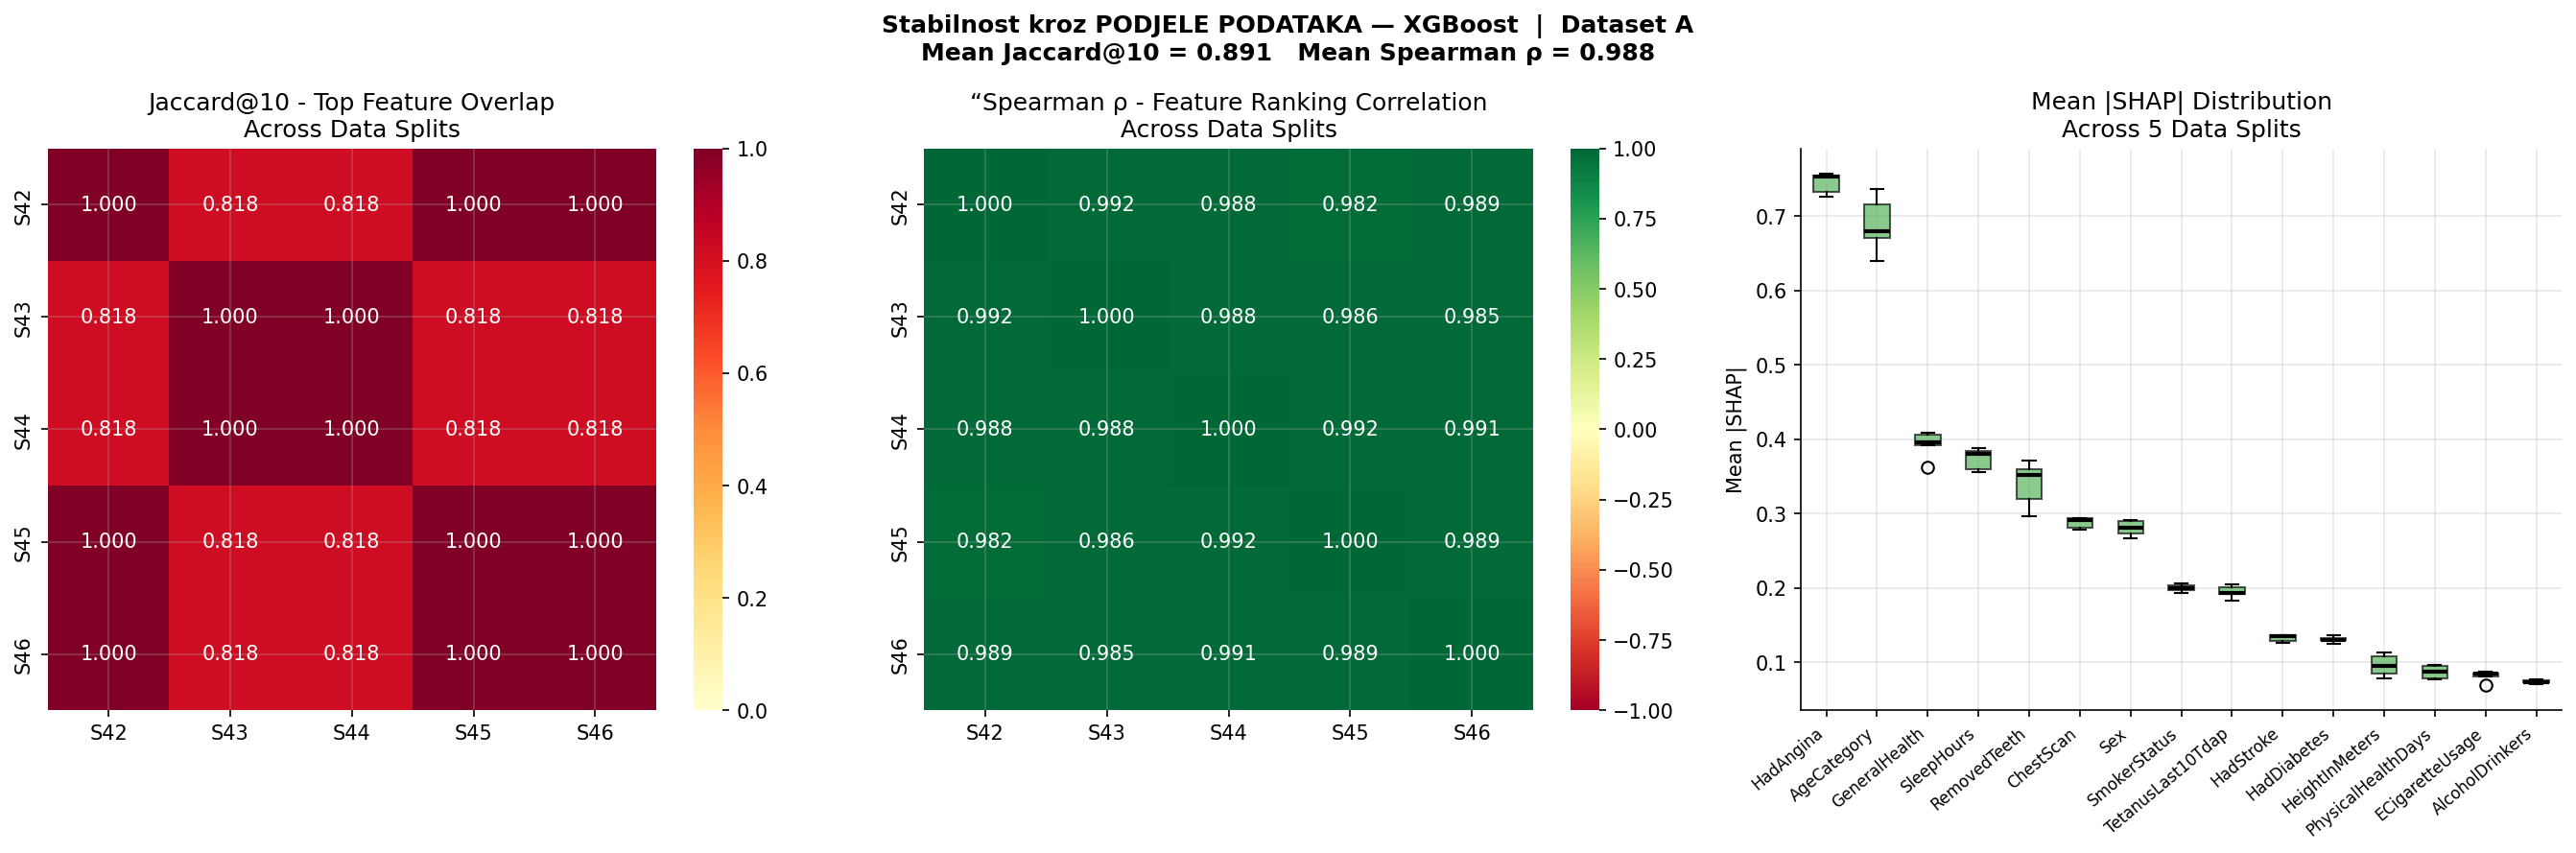

Sacuvano: figures/xai/S6_split_stability_A.png


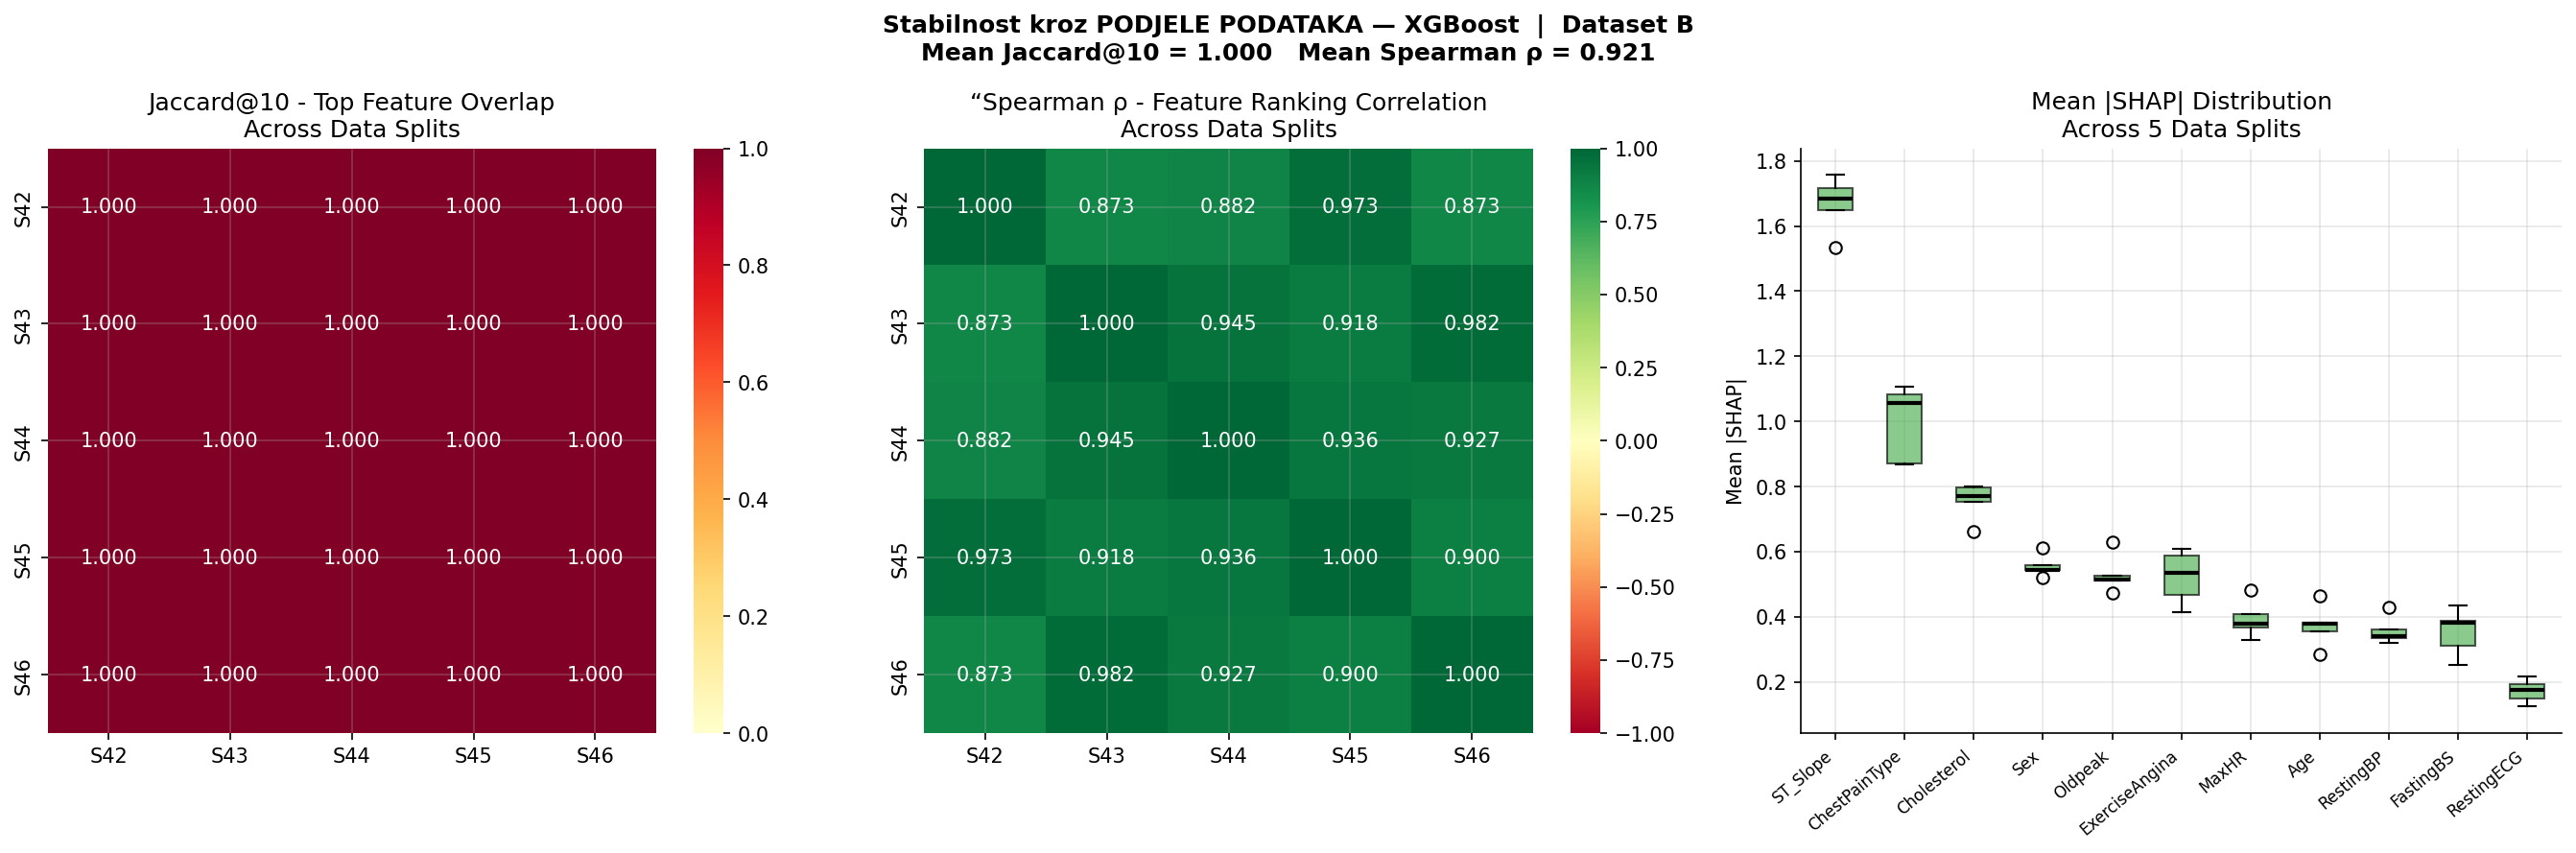

Sacuvano: figures/xai/S6_split_stability_B.png


In [18]:
# Vizualizacija stabilnosti kroz podjele 

for ds_key, sd in split_stability.items():
    shap_means = np.array(sd['shap_means'])
    feat_names = sd['feat_names']
    top_idx = np.argsort(shap_means.mean(axis=0))[::-1][:15]
    top_feats = [feat_names[i] for i in top_idx]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Jaccard heatmap
    sns.heatmap(sd['jac_mat'], annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[f'S{s}' for s in SPLIT_SEEDS],
                yticklabels=[f'S{s}' for s in SPLIT_SEEDS],
                ax=axes[0], vmin=0, vmax=1, annot_kws={'size': 10})
    axes[0].set_title(f'Jaccard@{K_SPLIT} - Top Feature Overlap\nAcross Data Splits')

    # 2. Spearman heatmap
    sns.heatmap(sd['cor_mat'], annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=[f'S{s}' for s in SPLIT_SEEDS],
                yticklabels=[f'S{s}' for s in SPLIT_SEEDS],
                ax=axes[1], vmin=-1, vmax=1, annot_kws={'size': 10})
    axes[1].set_title(f'“Spearman ρ - Feature Ranking Correlation\nAcross Data Splits')

    # 3. Box plotovi: varijabilnost SHAP po podjeli
    axes[2].boxplot([shap_means[:, i] for i in top_idx],
                    patch_artist=True, vert=True,
                    medianprops={'color': 'black', 'lw': 2},
                    boxprops={'facecolor': '#4CAF50', 'alpha': 0.65})
    axes[2].set_xticks(range(1, len(top_idx)+1))
    axes[2].set_xticklabels(top_feats, rotation=40, ha='right', fontsize=8)
    axes[2].set_ylabel('Mean |SHAP|')
    axes[2].set_title('Mean |SHAP| Distribution\nAcross 5 Data Splits')

    plt.suptitle(
        f'Stabilnost kroz PODJELE PODATAKA — {BEST_MODEL_NAME}  |  {sd["ds_label"]}\n'
        f'Mean Jaccard@{K_SPLIT} = {sd["mean_jac"]:.3f}   '
        f'Mean Spearman ρ = {sd["mean_cor"]:.3f}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    fname = f'figures/xai/S6_split_stability_{ds_key}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Sacuvano: {fname}')

## 6. Medicinska interpretabilnost - klinička validacija SHAP objašnjenja

Ova sekcija odgovara na pitanje: **"Da li SHAP i LIME rangiraju medicinski smislene faktore kao najvažnije?"**

Na osnovu etablirane literature (ACC/AHA 2023 smjernice, Framingham Risk Score, ESC Cardiovascular Prevention Guidelines) definišemo klinički očekivane faktore rizika za svaki dataset. Mjerimo koliki je udio top-K SHAP featura svakog modela usklađen s medicinskim znanjem.

In [19]:
# Medicinska interpretabilnost - definicija faktora rizika 

# ACC/AHA 2023, Framingham Risk Score, ESC Prevention Guidelines
MEDICAL_RISK_A = {
    'strong': [
        'HadAngina',  # Angina pectoris - direktan prediktor KBS
        'HadStroke',  # Prethodni mozdani udar - visok kardiovaskularni rizik
        'AgeCategory', # Starost - najjaci nezavisni faktor (Framingham)
        'GeneralHealth', # Opcenito zdravlje - proxy za komorbiditete
        'HadDiabetes',  # Dijabetes mellitus - 2-4x povecani rizik (AHA)
        'BMI',  # Indeks tjelesne mase - pretilost i kardiovaskularni rizik
        'SmokerStatus',  # Pusenje - 2-4x veci rizik za KBS
        'DifficultyWalking',  # Funkcionalna limitacija - marker uznapredovale KBS
        'HadCOPD',  # KOPB - cesta komorbidnost s KBS
        'HighRiskLastYear',  # Doktor procijenio visok kardiovaskularni rizik
        'PhysicalHealthDays', # Dani loseg fizickog zdravlja - kumulativni marker
        'ChestScan',  # Torakalni sken - screening za KBS
    ],
    'moderate': [
        'PhysicalActivities', # Fizicka neaktivnost - umjereni rizik (WHO)
        'HadArthritis', # Reumatoidni artritis - upalni marker
        'HadKidneyDisease', # Hronicna bubrezna bolest - kardiorenalni sindrom
        'SleepHours', # Poremecaj sna - kardiovaskularni rizik
        'MentalHealthDays', # Mentalno zdravlje - veza s KBS
        'RemovedTeeth', # Periodontolosko zdravlje - upalni marker
        'HadDepressiveDisorder', # Depresija - povecani kardiovaskularni rizik
        'AlcoholDrinkers', # Konzumacija alkohola - umjereni rizik
        'DifficultyErrands', # Funkcionalna ogranicenost
        'HadAsthma', # Astma - sistemska upala
    ]
}

MEDICAL_RISK_B = {
    'strong': [
        'ST_Slope', # Nagib ST segmenta - kljucni EKG marker ishemije
        'ChestPainType', # Tip bola u grudima - dijagnosticki kriterij ACS
        'ExerciseAngina',  # Angina na napor - dokaz miokardne ishemije
        'Oldpeak',  # ST depresija - kolicinari marker ishemije
        'MaxHR', # Maksimalni puls - kardiovaskularna rezerva
        'Age', # Starost - nezavisni faktor rizika
        'Sex', # Spol - rizik se razlikuje (muski visi do 65g)
    ],
    'moderate': [
        'Cholesterol', # Ukupni holesterol - ateroskleroza
        'RestingBP', # Krvni pritisak u mirovanju - hipertenzija
        'FastingBS', # Secer nataste - dijabetes screening
        'RestingECG', # EKG nalaz u mirovanju - elektricna aktivnost srca
    ]
}

medical_risks = {'A': MEDICAL_RISK_A, 'B': MEDICAL_RISK_B}
TOP_CLINICAL = 10


def clinical_score(shap_dict, feat_names, risk_dict, top_k=10):
    all_exp = set(risk_dict['strong']) | set(risk_dict.get('moderate', []))
    strong_exp = set(risk_dict['strong'])
    scores = {}
    for mname, sv in shap_dict.items():
        mean_abs = np.abs(sv).mean(axis=0)
        top_idx = np.argsort(mean_abs)[::-1][:top_k]
        top_feats = set(feat_names[i] for i in top_idx)
        in_exp = top_feats & all_exp
        in_str = top_feats & strong_exp
        scores[mname] = {
            'score_pct': len(in_exp) / top_k,
            'score_strong': len(in_str) / len(strong_exp),
            'n_expected': len(in_exp),
            'n_strong': len(in_str),
            'top_feats': top_feats,
            'in_expected': in_exp,
            'not_expected': top_feats - all_exp,
        }
    return scores


clinical_scores = {}

for ds_key, shap_dict, feat_names, ds_lbl in [
    ('A', shap_values_a, feature_names_a, 'Dataset A - CDC 2022'),
    ('B', shap_values_b, feature_names_b, 'Dataset B - Heart Failure'),
]:
    risk_dict = medical_risks[ds_key]
    scores = clinical_score(shap_dict, feat_names, risk_dict, TOP_CLINICAL)
    clinical_scores[ds_key] = scores

    print()
    print('=' * 80)
    print(f'MEDICINSKA INTERPRETABILNOST SHAP OBJASNJENJA  |  {ds_lbl}')
    print(f'Top-{TOP_CLINICAL} SHAP featura  vs  klinicki ocekivani faktori rizika')
    print('=' * 80)
    print(f'{"Model":<24} {"Ocekivani":>12} {"Jaki faktori":>13}  '
          f'{"Udio top-10":>12}  Neocekvani featurei')
    print('-' * 80)
    for mname, sc in sorted(scores.items(), key=lambda x: -x[1]['score_pct']):
        print(f'{mname:<24}  '
              f'{sc["n_expected"]:>5}/{TOP_CLINICAL}        '
              f'{sc["n_strong"]:>5}/{len(risk_dict["strong"])}         '
              f'{sc["score_pct"]*100:>8.1f}%   '
              f'{sorted(sc["not_expected"])}')
    print('=' * 80)

    all_top = set().union(*[sc['top_feats'] for sc in scores.values()])
    missed = set(risk_dict['strong']) - all_top
    if missed:
        print(f'Jaki faktori koje NIJEDAN model nije stavio u top-{TOP_CLINICAL}:')
        for f in sorted(missed):
            print(f' - {f}')
        print('=' * 80)


MEDICINSKA INTERPRETABILNOST SHAP OBJASNJENJA  |  Dataset A - CDC 2022
Top-10 SHAP featura  vs  klinicki ocekivani faktori rizika
Model                       Ocekivani  Jaki faktori   Udio top-10  Neocekvani featurei
--------------------------------------------------------------------------------
Random Forest                 9/10            7/12             90.0%   ['Sex']
Logistic Regression           8/10            6/12             80.0%   ['LastCheckupTime', 'Sex']
XGBoost                       8/10            6/12             80.0%   ['Sex', 'TetanusLast10Tdap']
LightGBM                      7/10            5/12             70.0%   ['HeightInMeters', 'Sex', 'TetanusLast10Tdap']
CatBoost                      7/10            5/12             70.0%   ['ECigaretteUsage', 'Sex', 'TetanusLast10Tdap']
Jaki faktori koje NIJEDAN model nije stavio u top-10:
 - BMI
 - DifficultyWalking
 - HadCOPD
 - HighRiskLastYear

MEDICINSKA INTERPRETABILNOST SHAP OBJASNJENJA  |  Dataset B - Heart Failu

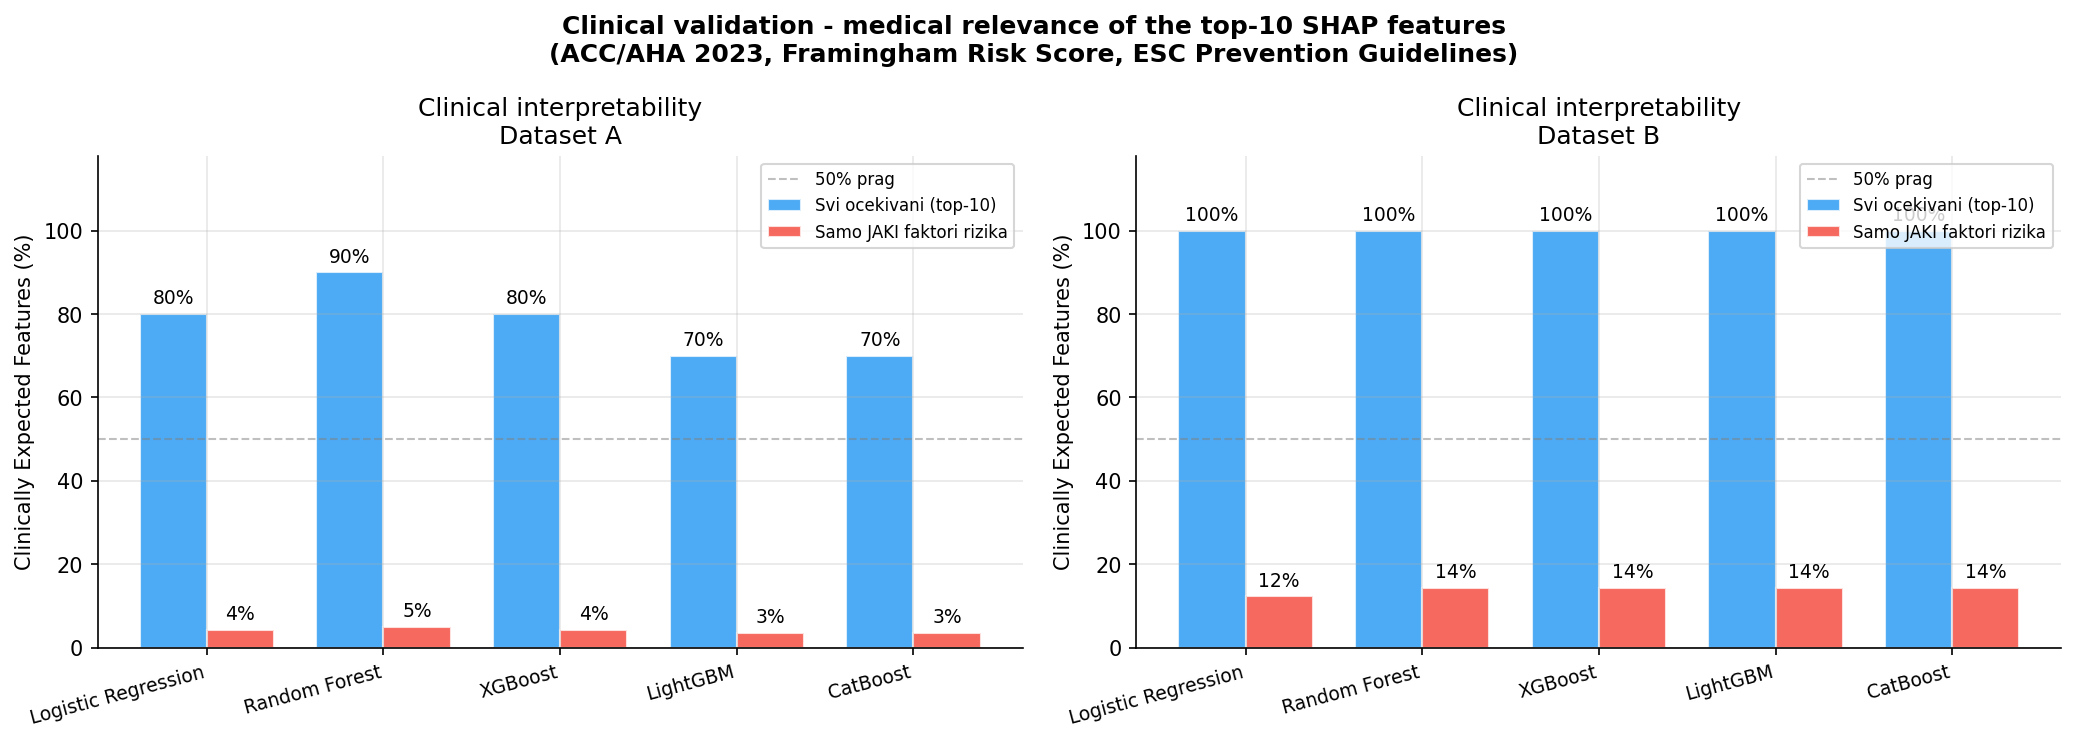

Sacuvano: figures/xai/S6_clinical_interpretability.png


In [20]:
# Vizualizacija medicinske interpretabilnosti 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (ds_key, ds_lbl) in zip(axes, [('A', 'Dataset A'), ('B', 'Dataset B')]):
    if ds_key not in clinical_scores:
        ax.axis('off'); continue
    scores = clinical_scores[ds_key]
    models = list(scores.keys())
    pct_exp = [scores[m]['score_pct'] * 100 for m in models]
    pct_str = [scores[m]['score_strong'] / len(medical_risks[ds_key]['strong']) * 100
               for m in models]

    x = np.arange(len(models));  w = 0.38
    b1 = ax.bar(x - w/2, pct_exp, w, label=f'Svi ocekivani (top-{TOP_CLINICAL})',
                color='#2196F3', alpha=0.80, edgecolor='white')
    b2 = ax.bar(x + w/2, pct_str, w, label='Samo JAKI faktori rizika',
                color='#F44336', alpha=0.80, edgecolor='white')
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Clinically Expected Features (%)')
    ax.set_title(f'Clinical interpretability\n{ds_lbl}')
    ax.set_ylim(0, 118)
    ax.axhline(y=50, color='grey', lw=1, linestyle='--', alpha=0.5, label='50% prag')
    ax.legend(fontsize=8)

plt.suptitle(
    f'Clinical validation - medical relevance of the top-{TOP_CLINICAL} SHAP features\n'
    '(ACC/AHA 2023, Framingham Risk Score, ESC Prevention Guidelines)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figures/xai/S6_clinical_interpretability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/xai/S6_clinical_interpretability.png')

## 7. Finalna sintezna tabela - Performanse + Stabilnost + Klinička interpretabilnost

Ovo je **centralni doprinos rada**: modeli se porede prema tri dimenzije, a ne samo prema prediktivnim performansama.

**Composite score** = `0.40 × ROC-AUC + 0.20 × F1(macro) + 0.20 × Stabilnost(Jaccard) + 0.20 × Klinička(%)`

Ova tabela direktno odgovara na pitanje: **„Koji model daje najbolji balans između tačnosti, objašnjivosti i kliničke interpretabilnosti?"**


FINALNA SINTEZNA TABELA | Dataset A - CDC 2022
Stabilnost: podjele (Jaccard=0.891, Spearman=0.988)
Composite = 0.40*ROC-AUC + 0.20*F1mac + 0.20*Stab.Jac + 0.20*Klin
Model                     ROC-AUC  F1mac Rec(HD)   BalAcc  Stab.Jac  Stab.Spr   Klin%  SHP-PFI  Composite
----------------------------------------------------------------------------------------------------------------
XGBoost                    0.8865 0.6586  0.2471   0.6180    0.8909    0.9882     80%     0.667      0.8245
CatBoost                   0.8860 0.6577  0.2411   0.6156    0.8909    0.9882     70%       N/A      0.8041
LightGBM                   0.8858 0.6531  0.2366   0.6129    0.8909    0.9882     70%       N/A      0.8031
Random Forest              0.8791 0.7099  0.4375   0.7038    0.8909    0.9882     90%       N/A      0.8518
Logistic Regression        0.8780 0.6122  0.7648   0.7952    0.8909    0.9882     80%     0.667      0.8118
TabNet                     0.8616 0.6046  0.7364   0.7798    0.8909    0.98

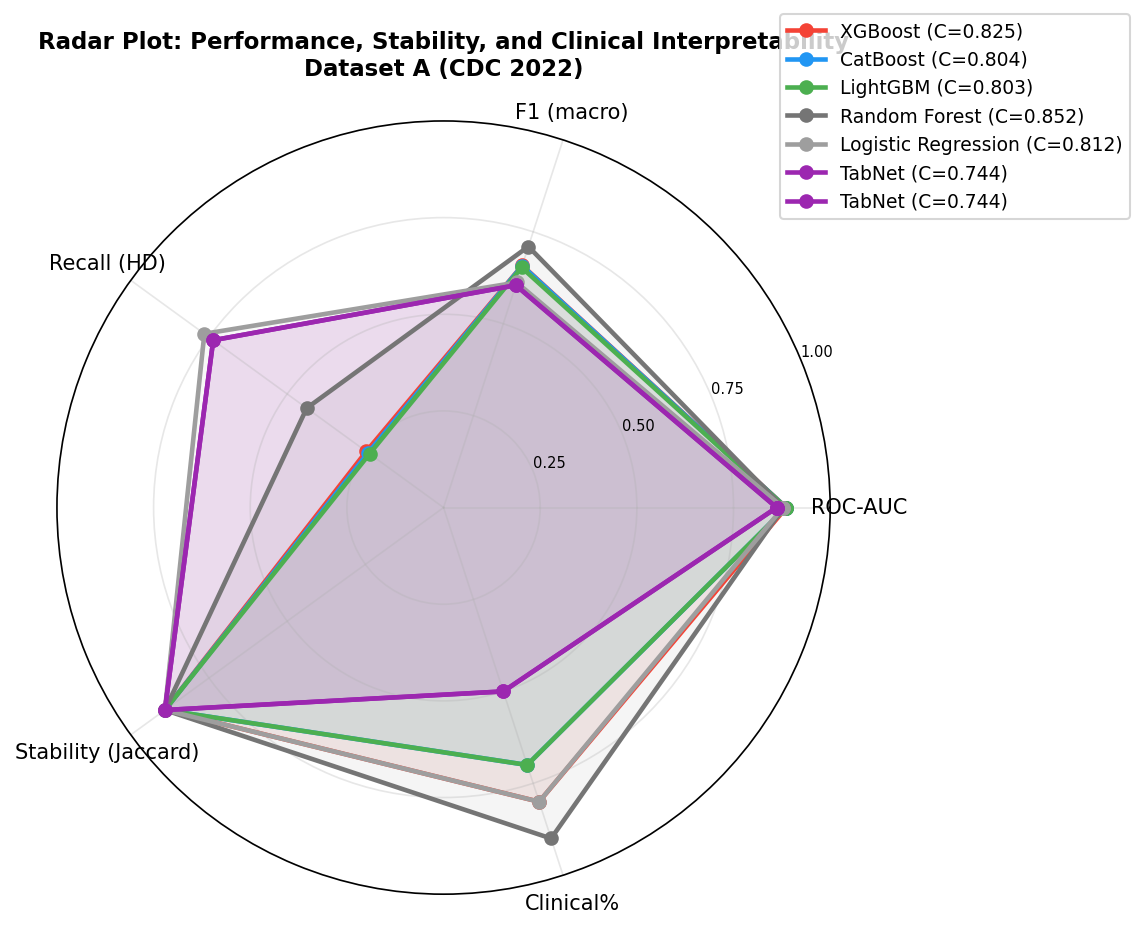

Sacuvano: figures/xai/S6_radar_A.png


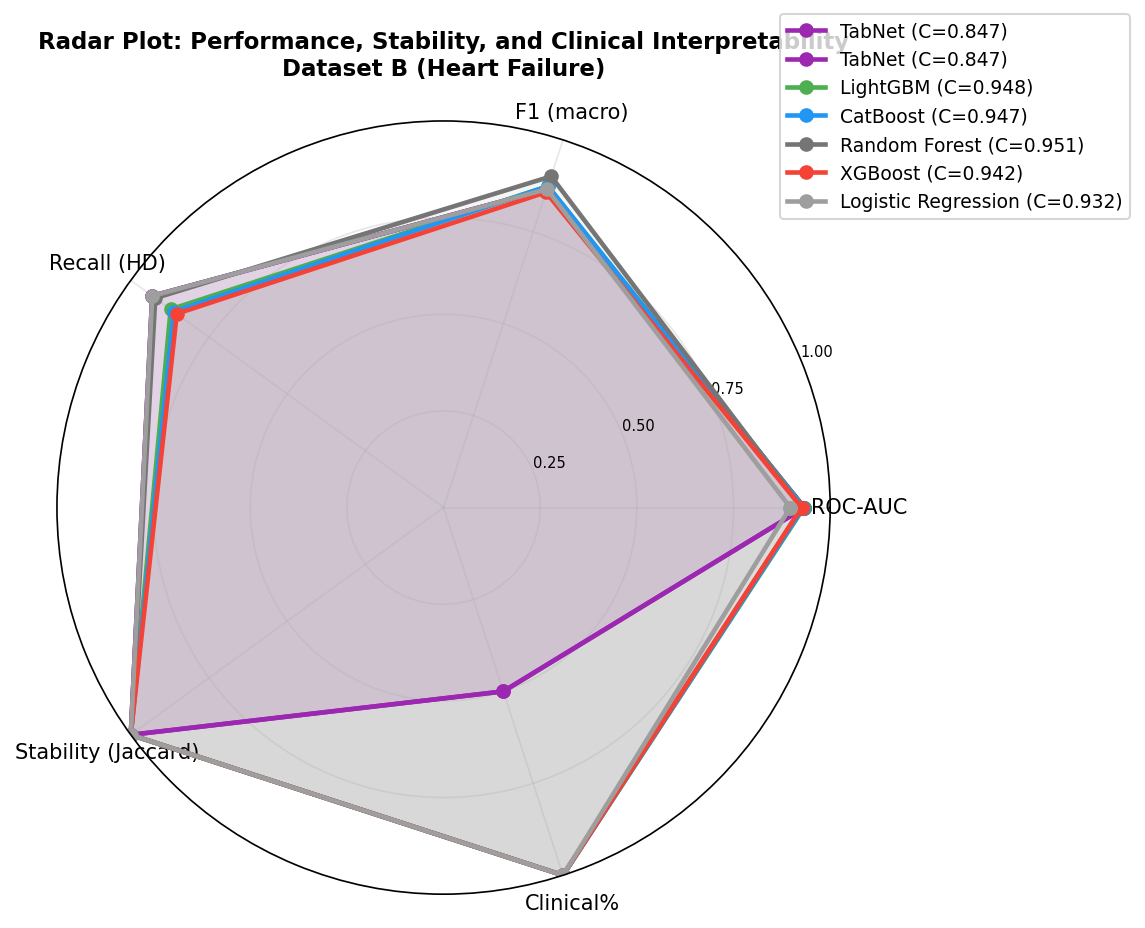

Sacuvano: figures/xai/S6_radar_B.png


In [21]:
# Finalna sintezna tabela 

W5 = 112
synthesis_rows = {}

for ds_key, ds_lbl_full in [
    ('A', 'Dataset A - CDC 2022'),
    ('B', 'Dataset B - Heart Failure'),
]:
    perf = combined_df[
        (combined_df['Dataset'] == f'Dataset {ds_key}') &
        (~combined_df['Model'].str.contains('tuned', case=False))
    ][['Model', 'ROC-AUC', 'F1 (macro)', 'Recall (HD)', 'Balanced Accuracy']].copy()

    # Stabilnost: preferiramo split_stability, fallback na stability_data (seeds)
    if ds_key in split_stability:
        stab_jac = split_stability[ds_key]['mean_jac']
        stab_cor = split_stability[ds_key]['mean_cor']
        stab_src = 'podjele'
    else:
        stab_jac = stability_data[ds_key]['jac_matrix'][np.triu_indices(5, k=1)].mean()
        stab_cor = stability_data[ds_key]['cor_matrix'][np.triu_indices(5, k=1)].mean()
        stab_src = 'seed-ovi'

    clin = clinical_scores.get(ds_key, {})

    def get_shap_pfi_jac(mname):
        key = f'{mname}_{ds_key}'
        if key not in pfi_results: return np.nan
        sd_ = shap_values_a if ds_key == 'A' else shap_values_b
        fn_ = feature_names_a if ds_key == 'A' else feature_names_b
        if mname not in sd_: return np.nan
        sv  = sd_[mname];  res = pfi_results[key]
        TOP = min(15, len(fn_))
        st  = set(np.argsort(np.abs(sv).mean(axis=0))[::-1][:TOP])
        pt  = set(np.argsort(res['importances_mean'])[::-1][:TOP])
        return len(st & pt) / len(st | pt)

    print()
    print('=' * W5)
    print(f'FINALNA SINTEZNA TABELA | {ds_lbl_full}')
    print(f'Stabilnost: {stab_src} (Jaccard={stab_jac:.3f}, Spearman={stab_cor:.3f})')
    print(f'Composite = 0.40*ROC-AUC + 0.20*F1mac + 0.20*Stab.Jac + 0.20*Klin')
    print('=' * W5)
    print(
        f'{"Model":<24} {"ROC-AUC":>8} {"F1mac":>6} {"Rec(HD)":>7}  '
        f'{"BalAcc":>7} {"Stab.Jac":>9} {"Stab.Spr":>9}  '
        f'{"Klin%":>6} {"SHP-PFI":>8} {"Composite":>10}'
    )
    print('-' * W5)

    rows = []
    for _, r in perf.sort_values('ROC-AUC', ascending=False).iterrows():
        mname = r['Model']
        roc = r['ROC-AUC'];  f1m = r['F1 (macro)']
        rec = r['Recall (HD)']; ba = r['Balanced Accuracy']
        klin = clin[mname]['score_pct'] if mname in clin else np.nan
        sp_j = get_shap_pfi_jac(mname)
        klin_v = klin if not np.isnan(klin) else 0.5
        composite = 0.40*roc + 0.20*f1m + 0.20*stab_jac + 0.20*klin_v

        print(
            f'{mname:<24} {roc:>8.4f} {f1m:>6.4f} {rec:>7.4f}  '
            f'{ba:>7.4f} {stab_jac:>9.4f} {stab_cor:>9.4f}  '
            f'{"N/A" if np.isnan(klin) else f"{klin*100:.0f}%":>6}  '
            f'{"N/A" if np.isnan(sp_j) else f"{sp_j:.3f}":>8}  '
            f'{composite:>10.4f}'
        )
        rows.append({'Dataset': f'Dataset {ds_key}', 'Model': mname,
                     'ROC-AUC': roc, 'F1 (macro)': f1m, 'Recall (HD)': rec,
                     'Stability (Jaccard)': stab_jac, 'Stability (Spearman)': stab_cor,
                     'Clinical%': klin, 'SHAP-PFI Jac': sp_j, 'Composite': composite})

    print('=' * W5)
    best_c = max(rows, key=lambda x: x['Composite'])
    best_p = max(rows, key=lambda x: x['ROC-AUC'])
    print()
    print(f'Najbolji po ROC-AUC: {best_p["Model"]:24s} AUC = {best_p["ROC-AUC"]:.4f}')
    print(f'Najbolji Composite: {best_c["Model"]:24s}  C = {best_c["Composite"]:.4f}')
    if best_p['Model'] != best_c['Model']:
        print(f'*** Najtacniji model != Najinterpretabilniji/Najstabilniji ***')
        print(f'--> Ovo je kljucni nalaz rada (research finding)')
    else:
        print(f'--> Najtacniji = Najinterpretabilniji/Najstabilniji')
    print('=' * W5)
    synthesis_rows[ds_key] = rows

# Radar chart: performanse + stabilnost + klinicka 

for ds_key, rows in synthesis_rows.items():
    if len(rows) < 2: continue
    ds_lbl = 'Dataset A (CDC 2022)' if ds_key == 'A' else 'Dataset B (Heart Failure)'

    metrics_r = ['ROC-AUC', 'F1 (macro)', 'Recall (HD)', 'Stability (Jaccard)', 'Clinical%']
    n_m = len(metrics_r); angles = np.linspace(0, 2*np.pi, n_m, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    c_list = ['#9E9E9E','#757575','#F44336','#4CAF50','#2196F3','#9C27B0','#FF9800']

    for ci, row in enumerate(rows):
        vals = [row['ROC-AUC'], row['F1 (macro)'], row['Recall (HD)'],
                row['Stability (Jaccard)'],
                row['Clinical%'] if not np.isnan(row['Clinical%']) else 0.5]
        vals += vals[:1]
        color = MODEL_COLORS_XAI.get(row['Model'], c_list[ci % len(c_list)])
        ax.plot(angles, vals, 'o-', lw=2.2, color=color,
                label=f'{row["Model"]} (C={row["Composite"]:.3f})')
        ax.fill(angles, vals, alpha=0.07, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_r, fontsize=10)
    ax.set_ylim(0, 1);  ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.00'], fontsize=7)
    ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
    ax.set_title(
        f'Radar Plot: Performance, Stability, and Clinical Interpretability\n{ds_lbl}',
        fontsize=11, fontweight='bold', pad=22
    )
    plt.tight_layout()
    fname = f'figures/xai/S6_radar_{ds_key}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Sacuvano: {fname}')

## 5. Usporedba SHAP rankinga - Dataset A vs Dataset B

Poređenje feature importance rezultata između velikog anketnog dataseta (A) i manjeg kliničkog dataseta (B) odgovara na ključno istraživačko pitanje: **"Da li se feature importance razlikuje između populacijskih i kliničkih podataka?"** Direktna usporedba featura je ograničena jer su skupovi featura različiti (39 vs 11), ali možemo analizirati konceptualne kategorije (demografski, srčani, životni stil).

In [22]:
# Cross-dataset SHAP usporedba 

# Kategorije featura (medicinska klasifikacija)
# Dataset A
categories_a = {
    'Demographic': ['AgeCategory', 'Sex', 'RaceEthnicityCategory', 'State'],
    'Cardiovascular': ['HadAngina', 'HadStroke', 'ChestScan', 'HighRiskLastYear'],
    'Metabolic': ['BMI', 'WeightInKilograms', 'HeightInMeters', 'HadDiabetes'],
    'Lifestyle': ['SmokerStatus', 'AlcoholDrinkers', 'PhysicalActivities',
                  'SleepHours', 'ECigaretteUsage'],
    'General Health': ['GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays'],
    'Comorbidities': ['HadArthritis', 'HadCOPD', 'HadKidneyDisease', 'HadAsthma',
                      'HadSkinCancer', 'HadDepressiveDisorder'],
    'Functional': ['DifficultyWalking', 'DifficultyConcentrating',
                   'DifficultyErrands', 'DifficultyDressingBathing'],
    'Other': ['HadHeartAttack', 'FluVaxLast12', 'PneumoVaxEver',
              'TetanusLast10Tdap', 'HIVTesting', 'CovidPos',
              'LastCheckupTime', 'RemovedTeeth', 'DeafOrHardOfHearing',
              'BlindOrVisionDifficulty'],
}

# Dataset B
categories_b = {
    'Demographic': ['Age', 'Sex'],
    'Cardiovascular': ['ChestPainType', 'RestingECG', 'ExerciseAngina',
                       'Oldpeak', 'ST_Slope', 'MaxHR'],
    'Metabolic': ['Cholesterol', 'FastingBS', 'RestingBP'],
}


def shap_by_category(sv, feat_names, cat_dict):
    """Sumira mean |SHAP| po kategoriji."""
    mean_abs = np.abs(sv).mean(axis=0)
    cat_sums = {}
    for cat, feats in cat_dict.items():
        idx_list = [feat_names.index(f) for f in feats if f in feat_names]
        cat_sums[cat] = mean_abs[idx_list].sum() if idx_list else 0.0
    return cat_sums


if BEST_MODEL_NAME in shap_values_a and BEST_MODEL_NAME in shap_values_b:
    cat_sum_a = shap_by_category(shap_values_a[BEST_MODEL_NAME], feature_names_a, categories_a)
    cat_sum_b = shap_by_category(shap_values_b[BEST_MODEL_NAME], feature_names_b, categories_b)

    # Normalizacija na [0, 1]
    total_a = sum(cat_sum_a.values())
    total_b = sum(cat_sum_b.values())
    cat_pct_a = {k: v / total_a for k, v in cat_sum_a.items() if v > 0}
    cat_pct_b = {k: v / total_b for k, v in cat_sum_b.items() if v > 0}

    print()
    print('=' * 70)
    print(f'SHAP po kategoriji featura | {BEST_MODEL_NAME}')
    print('=' * 70)
    print(f'{"Kategorija":<20} {"Dataset A":>12} {"Dataset B":>12}')
    print('-' * 70)
    all_cats = sorted(set(list(cat_pct_a.keys()) + list(cat_pct_b.keys())))
    for cat in all_cats:
        va = f'{cat_pct_a.get(cat, 0.0):.3f}'
        vb = f'{cat_pct_b.get(cat, 0.0):.3f}'
        print(f'{cat:<20} {va:>12} {vb:>12}')
    print('=' * 70)


SHAP po kategoriji featura | XGBoost
Kategorija              Dataset A    Dataset B
----------------------------------------------------------------------
Cardiovascular              0.232        0.655
Comorbidities               0.037        0.000
Demographic                 0.211        0.124
Functional                  0.014        0.000
General Health              0.108        0.000
Lifestyle                   0.159        0.000
Metabolic                   0.063        0.221
Other                       0.176        0.000


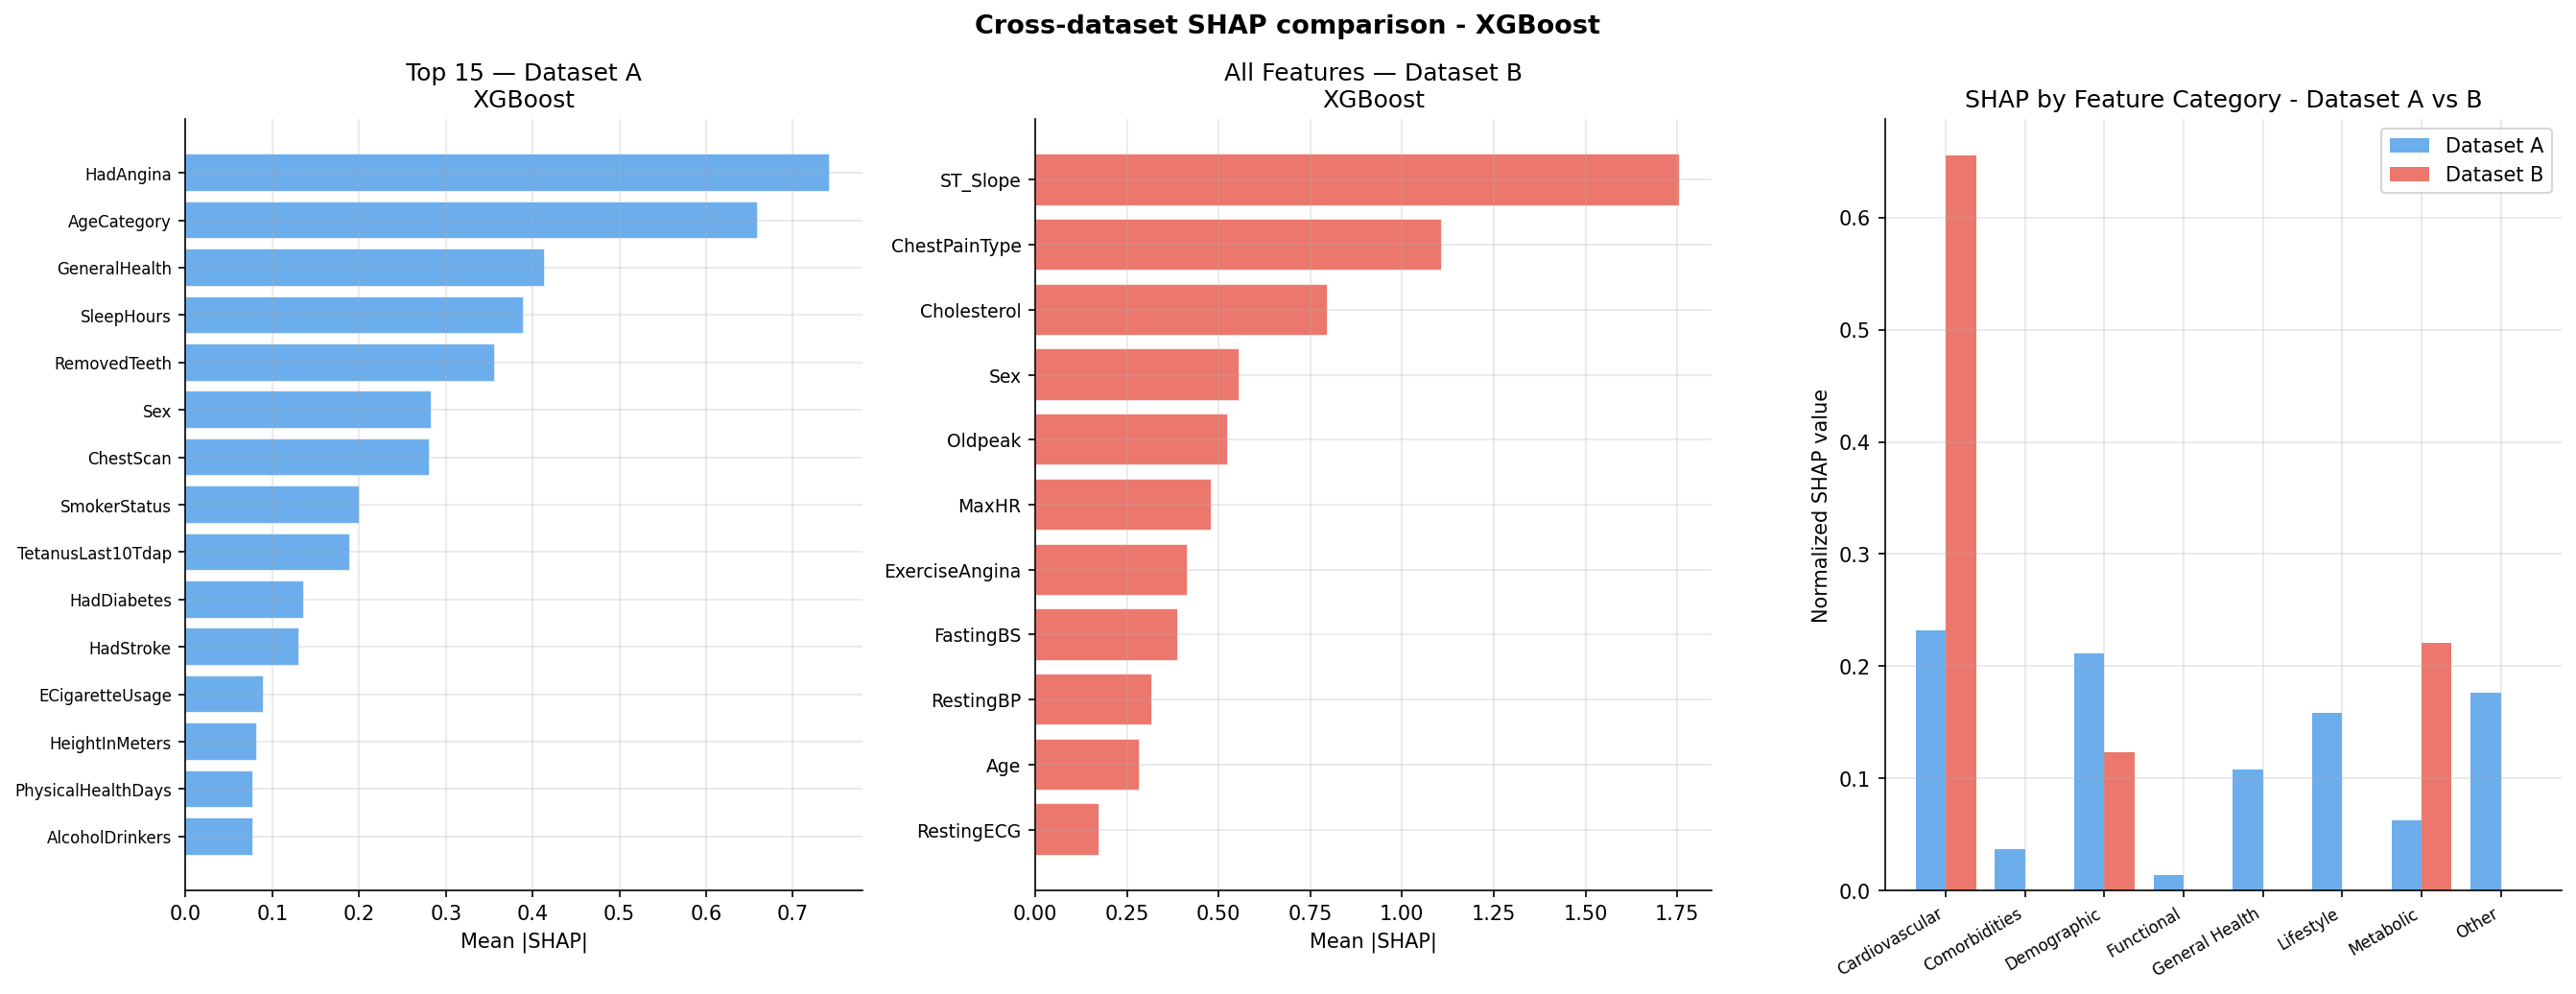

Sacuvano: figures/xai/S6_cross_dataset.png


In [23]:
# Cross-dataset vizualizacija 

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# 1. Bar: top-15 Dataset A
ax = axes[0]
sv_a = shap_values_a[BEST_MODEL_NAME]
ma_a = np.abs(sv_a).mean(axis=0)
idx_a = np.argsort(ma_a)[::-1][:15]
ax.barh(range(15), ma_a[idx_a][::-1],
        color='#4C9BE8', alpha=0.82, edgecolor='white')
ax.set_yticks(range(15))
ax.set_yticklabels([feature_names_a[i] for i in idx_a][::-1], fontsize=8)
ax.set_xlabel('Mean |SHAP|')
ax.set_title(f'Top 15 — Dataset A\n{BEST_MODEL_NAME}')

# 2. Bar: top-15 Dataset B (ili sve ako < 15)
ax = axes[1]
sv_b = shap_values_b[BEST_MODEL_NAME]
ma_b = np.abs(sv_b).mean(axis=0)
n_feat_b = len(feature_names_b)
idx_b = np.argsort(ma_b)[::-1][:n_feat_b]
ax.barh(range(n_feat_b), ma_b[idx_b][::-1],
        color='#E8594C', alpha=0.82, edgecolor='white')
ax.set_yticks(range(n_feat_b))
ax.set_yticklabels([feature_names_b[i] for i in idx_b][::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP|')
ax.set_title(f'All Features — Dataset B\n{BEST_MODEL_NAME}')

# 3. Kategorijska usporedba
ax = axes[2]
if 'cat_pct_a' in dir() and 'cat_pct_b' in dir():
    all_cats_plot = sorted(set(list(cat_pct_a.keys()) + list(cat_pct_b.keys())))
    vals_a_plot = [cat_pct_a.get(c, 0) for c in all_cats_plot]
    vals_b_plot = [cat_pct_b.get(c, 0) for c in all_cats_plot]

    x_c = np.arange(len(all_cats_plot))
    w_c = 0.38
    ax.bar(x_c - w_c/2, vals_a_plot, w_c, label='Dataset A', color='#4C9BE8', alpha=0.82)
    ax.bar(x_c + w_c/2, vals_b_plot, w_c, label='Dataset B', color='#E8594C', alpha=0.82)
    ax.set_xticks(x_c)
    ax.set_xticklabels(all_cats_plot, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Normalized SHAP value')
    ax.set_title('SHAP by Feature Category - Dataset A vs B')
    ax.legend()

plt.suptitle(f'Cross-dataset SHAP comparison - {BEST_MODEL_NAME}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/xai/S6_cross_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/xai/S6_cross_dataset.png')

In [24]:
# Finalni XAI summary ispis 

W4 = 72
print()
print('=' * W4)
print('XAI ANALIZA — SUMMARY')
print('=' * W4)
print(f'Best model (po ROC-AUC, Dataset A): {BEST_MODEL_NAME}')
print()

# SHAP summary
print('[SHAP] Top-5 featura po datasetu:')
for ds_k, shap_dict, feat_names, ds_l in [
    ('A', shap_values_a, feature_names_a, 'Dataset A'),
    ('B', shap_values_b, feature_names_b, 'Dataset B'),
]:
    if BEST_MODEL_NAME not in shap_dict:
        continue
    sv = shap_dict[BEST_MODEL_NAME]
    top5 = np.argsort(np.abs(sv).mean(axis=0))[::-1][:5]
    print(f'{ds_l}: {[feat_names[i] for i in top5]}')

# Stabilnost
print()
print('[Stabilnost]')
for ds_k, sd in stability_data.items():
    jac_vals = sd['jac_matrix'][np.triu_indices(len(STABILITY_SEEDS), k=1)]
    cor_vals = sd['cor_matrix'][np.triu_indices(len(STABILITY_SEEDS), k=1)]
    print(f' {sd["ds_label"]}: '
          f'Mean Jaccard@{K_STAB}={jac_vals.mean():.3f}  '
          f'Mean Spearman={cor_vals.mean():.3f}')

# PFI vs SHAP
print()
print('[SHAP vs PFI konzistentnost]')
for ds_key in ['A', 'B']:
    key = f'{BEST_MODEL_NAME}_{ds_key}'
    if key not in pfi_results:
        continue
    ds_lbl = 'Dataset A' if ds_key == 'A' else 'Dataset B'
    shap_d = shap_values_a if ds_key == 'A' else shap_values_b
    feat_n = feature_names_a if ds_key == 'A' else feature_names_b
    if BEST_MODEL_NAME not in shap_d:
        continue
    sv = shap_d[BEST_MODEL_NAME]
    res = pfi_results[key]
    TOP = min(15, len(feat_n))
    shap_top = set(np.argsort(np.abs(sv).mean(axis=0))[::-1][:TOP])
    pfi_top  = set(np.argsort(res['importances_mean'])[::-1][:TOP])
    jac = len(shap_top & pfi_top) / len(shap_top | pfi_top)
    cor, _ = spearmanr(
        [list(np.argsort(np.argsort(-np.abs(sv).mean(axis=0)))).index(i)
         for i in range(len(feat_n))],
        [list(np.argsort(np.argsort(-res['importances_mean']))).index(i)
         for i in range(len(feat_n))]
    )
    print(f' {ds_lbl}: Jaccard@{TOP}={jac:.3f} Spearman={cor:.3f}')

print()
print('=' * W4)


XAI ANALIZA — SUMMARY
Best model (po ROC-AUC, Dataset A): XGBoost

[SHAP] Top-5 featura po datasetu:
Dataset A: ['HadAngina', 'AgeCategory', 'GeneralHealth', 'SleepHours', 'RemovedTeeth']
Dataset B: ['ST_Slope', 'ChestPainType', 'Cholesterol', 'Sex', 'Oldpeak']

[Stabilnost]
 Dataset A: Mean Jaccard@10=0.891  Mean Spearman=0.992
 Dataset B: Mean Jaccard@10=1.000  Mean Spearman=0.985

[SHAP vs PFI konzistentnost]
 Dataset A: Jaccard@15=0.667 Spearman=0.035
 Dataset B: Jaccard@11=1.000 Spearman=0.527



In [25]:
# Cuvanje XAI rezultata 

xai_output = {
    'shap_values_a': shap_values_a,
    'shap_values_b': shap_values_b,
    'all_rankings_a': all_rankings_a,
    'all_rankings_b': all_rankings_b,
    'pfi_results': pfi_results,
    'stability_data': stability_data,
    'best_model_name': BEST_MODEL_NAME,
    'stability_seeds': STABILITY_SEEDS,
    'shap_sample_a': X_shap_a,
    'shap_sample_b': X_shap_b,
    'shap_idx_a': idx_shap,
}

with open('models/xai_results.pkl', 'wb') as f:
    pickle.dump(xai_output, f)

print('Sacuvano: models/xai_results.pkl')
print()
print('Figure sacuvane u: figures/xai/')
for fname in sorted(os.listdir('figures/xai')):
    print(f'{fname}')
print()
print('S6 -- XAI: ZAVRSEN!')

Sacuvano: models/xai_results.pkl

Figure sacuvane u: figures/xai/
S6_clinical_interpretability.png
S6_cross_dataset.png
S6_lime_A.png
S6_lime_B.png
S6_pfi.png
S6_radar_A.png
S6_radar_B.png
S6_shap_agreement_A.png
S6_shap_agreement_B.png
S6_shap_bar.png
S6_shap_beeswarm_A.png
S6_shap_beeswarm_B.png
S6_shap_dependence.png
S6_shap_waterfall.png
S6_split_stability_A.png
S6_split_stability_B.png
S6_stability_A.png
S6_stability_B.png

S6 -- XAI: ZAVRSEN!


## Zaključak 

### Pregled urađenog

1. **SHAP** - globalni bar/beeswarm plotovi za sve modele, waterfall za individualne primjere (TP/FN/TN/FP), dependence plotovi za top featuree, cross-model rang-korelacija
2. **LIME** - 4 lokalna objašnjenja (TP, FN, TN, FP) za best model na oba dataseta
3. **PFI** - permutation importance s error barovima (ROC-AUC drop), poređenje sa SHAP (Jaccard + Spearman)
4. **Stabilnost** - 5 seed-ova, Jaccard@K, Spearman ρ, rank varijabilnost, box plotovi distribucije SHAP kroz seed-ove
5. **Cross-dataset** - kategorijska analiza SHAP doprinosa, side-by-side ranking, Dataset A vs B